# SIMPlex Breast Cancer — extra exploration

Starts from the deposited cross-patient Harmony-integrated object (`SIMPlex_breast_allSamples.rds`). No upstream merge or integration re-run required.


In [4]:
# DATA_ROOT, HDF5 library, palettes — single source of truth for paths.
source(here::here("config.R"))

In [5]:
# HDF5 library is loaded by config.R
library(semla)
library(tibble)
library(Seurat)
options(Seurat.object.assay.version = "v5")
library(patchwork)
library(singlet)
library(RcppML)
library(ggplot2)
library(dplyr)
library(tidyr)
library(viridis)
library(pheatmap)
library(cowplot)
library(corrplot)
library(RColorBrewer)
library(heatmap3)
library(harmony)
library(gridExtra)
library(paletteer)
library(Matrix)

Loading required package: Seurat



Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

semla v1.3.1

Authors: Ludvig Larsson and Lovisa Franzen

Loading required package: RcppML

RcppML v0.5.5 using 'options(RcppML.threads = 0)' (all available threads), 'options(RcppML.verbose = FALSE)'

Warning message:
“replacing previous import ‘S4Arrays::makeNindexFromArrayViewport’ by ‘DelayedArray::makeNindexFromArrayViewport’ when loading ‘SummarizedExperiment’”

Attaching package: ‘singlet’


The following object is masked from ‘package:Seurat’:

    ProjectData


Loading required package: viridisLite


Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


corrplot 0.95 loaded

Loading required package: Rcpp


Attaching package: ‘gridExtra’


The following object 

### Settings


In [6]:
rootObj <- paste0(SN_RDS, "/breast_cancer/cross_patient/")

colsCelltype <- c("#EAE29CFF", "#6CC382FF", "#E99F69FF", "#CF597EFF", "#EAC17AFF", "#29AD8EFF", "#B2D387FF", "#E4796DFF", "#089392FF")
colsSample <- paletteer_c("grDevices::Dark 3", 10)
colsSubtype <- c("#6EA9B0", "#B1A6D1", "#E18A96")
colsMalignancy <- c("#84D7E1", "#6ABE8C", "#FF95A8")
colsAssays <- c("#6A5ACD", "#FFA500", "#20B2AA")

### Load data

`SIMPlex_breast_allSamples.rds` is ~8 GB. Expect several minutes to load and substantial RAM. Use the **R (simplex renv)** kernel.


In [9]:
int.all <- readRDS(file.path(rootObj, "SIMPlex_breast_allSamples.rds"))

## LR gene sanity check 
Dot + violin panel for key ligands (CXCL12, C3, THBS2) and receptors (CXCR4, C3AR1, CD47). Saved to `figs/review/LR_sanity_check/`.

In [58]:
# Seurat v5: use log-normalised RNA (not counts, not SCT, not scale.data)
expr_assay <- "RNA"
expr_layer <- "data"
DefaultAssay(int.all) <- expr_assay

pop_cols <- c(
  "iCAF_classical" = "#f6d46c",
  "iCAF_secretory" = "#c4a310",
  "mCAF_classical" = "#800000",
  "mCAF_remodeling" = "#990F02",
  "pDCs" = "#08519C",
  "Plasma_cells" = "#1CA9C9",
  "B_cells_activated" = "#6bd6d4",
  "B/T-mixed_patient4" = "#C6DBEF",
  "Cancer_Transitional_pat4" = "#FF6347",
  "Cancer_Basal/Plastic_pat4" = "#FF9900",
  "Cancer_Basal/Cycl_pat4" = "#B20000"
)

ligand_genes <- c("CXCL12", "C3", "THBS2")
receptor_genes <- c("CXCR4", "C3AR1", "CD47", "NOTCH3")

pat4_lr <- subset(int.all, subset = subpopulation %in% names(pop_cols))
pat4_lr$subpopulation <- factor(pat4_lr$subpopulation, levels = names(pop_cols))
Idents(pat4_lr) <- "subpopulation"

table(pat4_lr$subpopulation)

Warning message:
“Removing 11327 cells missing data for vars requested”



           iCAF-classical            iCAF-secretory            mCAF-classical 
                     1147                       346                      1126 
          mCAF-remodeling                      pDCs              Plasma-cells 
                      248                       288                       662 
        B-cells-activated        B/T-mixed-patient4  Cancer-Transitional-pat4 
                      687                       416                      1498 
Cancer-Basal/Plastic-pat4    Cancer-Basal/Cycl-pat4 
                     2915                       585 

In [59]:
wd_lr <- file.path(FIGS_ROOT, "review", "LR_sanity_check")
dir.create(wd_lr, recursive = TRUE, showWarnings = FALSE)

theme_lr <- theme_bw(base_size = 10) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, colour = "black"),
    plot.title = element_text(face = "bold", hjust = 0, size = 11),
    legend.title = element_text(size = 9),
    legend.text = element_text(size = 8)
  )

# DotPlot colours expression, not identity — colour population labels on y-axis
style_lr_dotplot <- function(p, pop_cols) {
  pop_labels <- levels(p$data$id)
  p + theme(
    axis.text.y = element_text(
      colour = unname(pop_cols[pop_labels]),
      size = 8,
      face = "bold"
    )
  )
}

# VlnPlot fill uses pop_cols via cols=; also colour population names on x-axis
style_lr_vlnplots <- function(plots, pop_cols) {
  lapply(plots, function(p) {
    pop_labels <- ggplot_build(p)$layout$panel_params[[1]]$x$get_labels()
    p + theme(
      axis.text.x = element_text(
        angle = 45,
        hjust = 1,
        size = 6.5,
        face = "bold",
        colour = unname(pop_cols[pop_labels])
      )
    )
  })
}

In [60]:
p_lig_dot <- style_lr_dotplot(
  DotPlot(
    pat4_lr,
    features = ligand_genes,
    group.by = "subpopulation",
    assay = expr_assay,
    scale = FALSE,
    cols = c("grey92", "#2166AC")
  ) +
    RotatedAxis() +
    labs(title = "Ligands", x = NULL, y = NULL, colour = "Avg expr") +
    theme_lr +
    theme(legend.position = "right"),
  pop_cols
)

p_rec_dot <- style_lr_dotplot(
  DotPlot(
    pat4_lr,
    features = receptor_genes,
    group.by = "subpopulation",
    assay = expr_assay,
    scale = FALSE,
    cols = c("grey92", "#B2182B")
  ) +
    RotatedAxis() +
    labs(title = "Receptors", x = NULL, y = NULL, colour = "Avg expr") +
    theme_lr +
    theme(legend.position = "right"),
  pop_cols
)

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


In [61]:
vln_lig <- style_lr_vlnplots(
  VlnPlot(
    pat4_lr,
    features = ligand_genes,
    assay = expr_assay,
    layer = expr_layer,
    group.by = "subpopulation",
    cols = pop_cols,
    pt.size = 0,
    combine = FALSE
  ),
  pop_cols
)
p_lig_vln <- wrap_plots(vln_lig, ncol = length(ligand_genes)) +
  plot_annotation(title = "Ligand expression distributions") &
  theme_lr &
  theme(legend.position = "none", axis.title.x = element_blank())

vln_rec <- style_lr_vlnplots(
  VlnPlot(
    pat4_lr,
    features = receptor_genes,
    assay = expr_assay,
    layer = expr_layer,
    group.by = "subpopulation",
    cols = pop_cols,
    pt.size = 0,
    combine = FALSE
  ),
  pop_cols
)
p_rec_vln <- wrap_plots(vln_rec, ncol = length(receptor_genes)) +
  plot_annotation(title = "Receptor expression distributions") &
  theme_lr &
  theme(legend.position = "none", axis.title.x = element_blank())

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text(

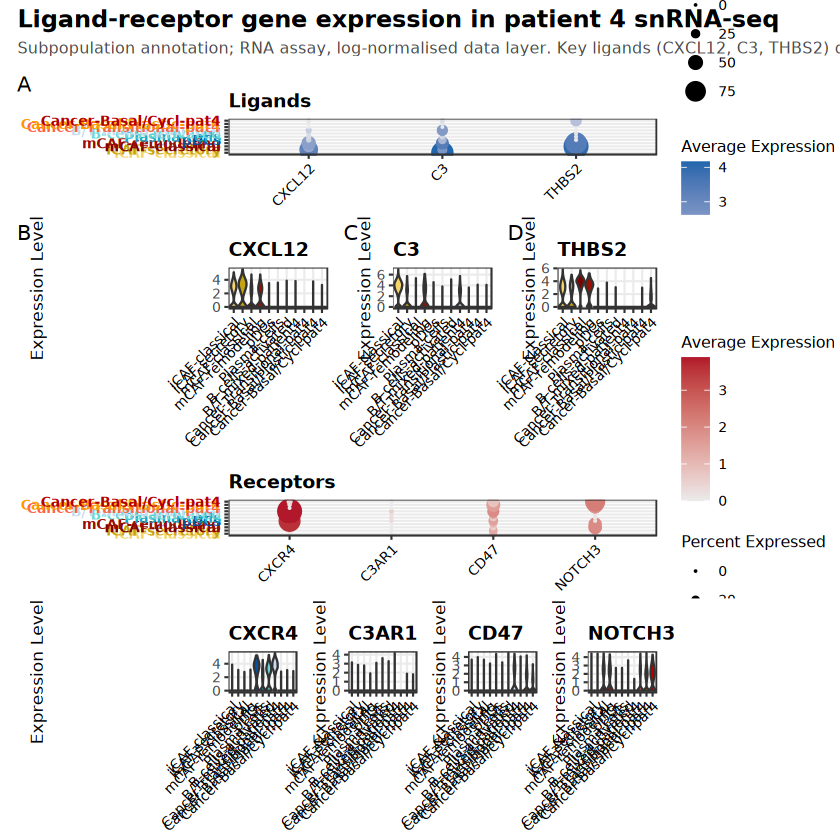

In [62]:
panel_lr <- (p_lig_dot / p_lig_vln / p_rec_dot / p_rec_vln) +
  plot_layout(heights = c(1, 1.15, 1, 1.15)) +
  plot_annotation(
    title = "Ligand-receptor gene expression in patient 4 snRNA-seq",
    subtitle = paste(
      "Subpopulation annotation; RNA assay, log-normalised data layer.",
      "Key ligands (CXCL12, C3, THBS2) detected in iCAF_classical;",
      "receptors (CXCR4, C3AR1, CD47) in pDCs, plasma / activated B cells, and transitional cancer."
    ),
    tag_levels = list(c("A", "B", "C", "D")),
    theme = theme(
      plot.title = element_text(face = "bold", size = 14, hjust = 0),
      plot.subtitle = element_text(size = 9.5, colour = "grey30", hjust = 0, lineheight = 1.15)
    )
  )

panel_lr

ggsave(
  file.path(wd_lr, "LR_snRNA_sanity_check.pdf"),
  plot = panel_lr, width = 14, height = 16, limitsize = FALSE
)
ggsave(
  file.path(wd_lr, "LR_snRNA_sanity_check.png"),
  plot = panel_lr, width = 14, height = 16, dpi = 300, limitsize = FALSE
)

## CAF, neutrophil, mast cell data robustness vs BC atlas

Major-lineage comparisons on SIMPlex vs BC atlas. Outputs: `figs/review/CAF_validation/`.


In [54]:
# === Data prep ===
wd_val <- file.path(FIGS_ROOT, "review", "CAF_validation")
dir.create(wd_val, recursive = TRUE, showWarnings = FALSE)

stopifnot(
  "population" %in% colnames(int.all@meta.data),
  "subpopulation" %in% colnames(int.all@meta.data)
)

bc_atlas <- readRDS(file.path(EXT_REFS, "BC_atlas/miniatlas.rds"))
bc_atlas <- UpdateSeuratObject(bc_atlas)
bc_atlas$celltype_major <- ifelse(
  bc_atlas$celltype_major %in% c("Normal Epithelial", "Cancer Epithelial"),
  "Epithelial", bc_atlas$celltype_major
)
if (!"percent.mt" %in% colnames(bc_atlas@meta.data)) {
  bc_atlas[["percent.mt"]] <- PercentageFeatureSet(bc_atlas, pattern = "^MT-")
}

meta_at <- function(obj, col) obj@meta.data[[col]][seq_len(ncol(obj))]

vs_rest_group <- function(obj, col, is_yes, yes, no = "Other") {
  vals <- meta_at(obj, col)
  match_yes <- is_yes(vals)
  match_yes[is.na(match_yes)] <- FALSE
  grp <- ifelse(match_yes, yes, no)
  grp[is.na(grp)] <- no
  factor(grp, levels = c(yes, no))
}

genes_both <- intersect(rownames(int.all[["RNA"]]), rownames(bc_atlas[["RNA"]]))

markers_panel <- function(pos, neg) {
  pos <- intersect(pos, genes_both)
  neg <- intersect(neg, genes_both)
  c(pos, neg)
}

caf_pos <- c(
  "FAP", "MMP11", "COMP", "POSTN", "COL1A1", "COL1A2", "COL3A1", "COL5A2",
  "CFD", "PLA2G2A", "APOD", "CXCL14", "CD34", "CXCL12", "IL6",
  "HLA-DRA", "HLA-DRB1", "CD74"
)
caf_neg <- c("EPCAM", "KRT8", "CD3D", "CD3E", "MS4A1", "TRAC", "CD163")
caf_markers <- markers_panel(caf_pos, caf_neg)

neut_pos <- c("S100A8", "S100A9", "CXCL8", "PTGS2", "VNN2", "MMP25", "FCGR3B", "CSF3R")
neut_neg <- c("CD3D", "MS4A1", "EPCAM", "CPA3", "KIT", "CD68", "CD163")
neutrophil_markers <- markers_panel(neut_pos, neut_neg)

mast_pos <- c("CPA3", "HDC", "KIT", "CTSG", "CMA1", "TPSG1", "MS4A2", "GATA2")
mast_neg <- c("CD3D", "MS4A1", "S100A8", "EPCAM", "CD68", "TRAC")
mast_markers <- markers_panel(mast_pos, mast_neg)

n_simp <- list(
  caf  = sum(int.all$population == "CAFs", na.rm = TRUE),
  neut = sum(int.all$subpopulation == "Neutrophils", na.rm = TRUE),
  mast = sum(int.all$subpopulation == "Mast_cells", na.rm = TRUE),
  pops = length(unique(int.all$population)),
  cells = ncol(int.all),
  samples = length(unique(int.all$sample)),
  genes = median(int.all$nFeature_RNA, na.rm = TRUE),
  mt = median(int.all$percent.mt, na.rm = TRUE)
)
n_atlas <- list(
  caf  = sum(bc_atlas$celltype_major == "CAFs", na.rm = TRUE),
  neut = 0L,
  mast = 0L,
  pops = length(unique(bc_atlas$celltype_major)),
  cells = ncol(bc_atlas),
  samples = length(unique(bc_atlas$Patient)),
  genes = median(bc_atlas$nFeature_RNA, na.rm = TRUE),
  mt = median(bc_atlas$percent.mt, na.rm = TRUE)
)

summary_df <- tibble::tibble(
  metric = factor(c(
    "CAF nuclei / cells",
    "Neutrophil nuclei",
    "Mast nuclei",
    "Major cell populations",
    "Samples / patients",
    "Total nuclei",
    "Median genes per nucleus",
    "Median % mitochondrial"
  ), levels = c(
    "CAF nuclei / cells",
    "Neutrophil nuclei",
    "Mast nuclei",
    "Major cell populations",
    "Samples / patients",
    "Total nuclei",
    "Median genes per nucleus",
    "Median % mitochondrial"
  )),
  SIMPlex = c(
    n_simp$caf, n_simp$neut, n_simp$mast, n_simp$pops,
    n_simp$samples, n_simp$cells, round(n_simp$genes, 0), round(n_simp$mt, 2)
  ),
  BC_atlas = c(
    n_atlas$caf, n_atlas$neut, n_atlas$mast, n_atlas$pops,
    n_atlas$samples, n_atlas$cells, round(n_atlas$genes, 0), round(n_atlas$mt, 2)
  )
)
write.csv(
  summary_df %>% rename(`BC atlas` = BC_atlas),
  file.path(wd_val, "validation_summary.csv"),
  row.names = FALSE
)

# Comparison specs (lineage vs rest, or major types for atlas)
plot_specs <- list(
  list(obj = int.all,   group = vs_rest_group(int.all,   "population",     function(x) x == "CAFs",         "CAFs"),         features = caf_markers,          title = paste0("SIMPlex: CAFs (n=", n_simp$caf, ") vs other")),
  list(obj = bc_atlas,  group = vs_rest_group(bc_atlas,  "celltype_major", function(x) x == "CAFs",         "CAFs"),         features = caf_markers,          title = paste0("BC atlas: CAFs (n=", n_atlas$caf, ") vs other")),
  list(obj = int.all,   group = vs_rest_group(int.all,   "subpopulation",  function(x) x == "Neutrophils",  "Neutrophils"),  features = neutrophil_markers,   title = paste0("SIMPlex: neutrophils (n=", n_simp$neut, ") vs other")),
  list(obj = bc_atlas,  group = factor(meta_at(bc_atlas, "celltype_major"), levels = sort(unique(bc_atlas$celltype_major))), features = neutrophil_markers, title = "BC atlas: all cells (no neutrophil lineage)"),
  list(obj = int.all,   group = vs_rest_group(int.all,   "subpopulation",  function(x) x == "Mast_cells",    "Mast cells"),   features = mast_markers,         title = paste0("SIMPlex: mast cells (n=", n_simp$mast, ") vs other")),
  list(obj = bc_atlas,  group = factor(meta_at(bc_atlas, "celltype_major"), levels = sort(unique(bc_atlas$celltype_major))), features = mast_markers,         title = "BC atlas: all cells (no mast cell lineage)")
)


Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘umap’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in pca

Updating slots in umap

Setting umap DimReduc to global

Setting assay used for NormalizeData.RNA to RNA

Setting assay used for FindVariableFeatures.RNA to RNA

Setting assay used for ScaleData.RNA to RNA

Setting assay used for RunPCA.RNA to RNA

Setting assay used for RunUMAP.RNA.pca to RNA

Validating object structure for Assay5 ‘RNA’

Validating object structure for DimReduc ‘pca’

Validating object structure for DimReduc ‘umap’

Object representation is consistent with the most current Seurat version



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Positive then negative markers (shared genes only). SIMPlex: lineage vs other; BC atlas: no neutrophil/mast lineage — all major types shown.' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Positive then negative markers (shared genes only). SIMPlex: lineage vs other; BC atlas: no neutrophil/mast lineage — all major types shown.' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Positive then negative markers (shared genes only). SIMPlex: lineage vs other; BC atlas: no neutrophil/mast lineage — all major types shown.' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Positive then nega

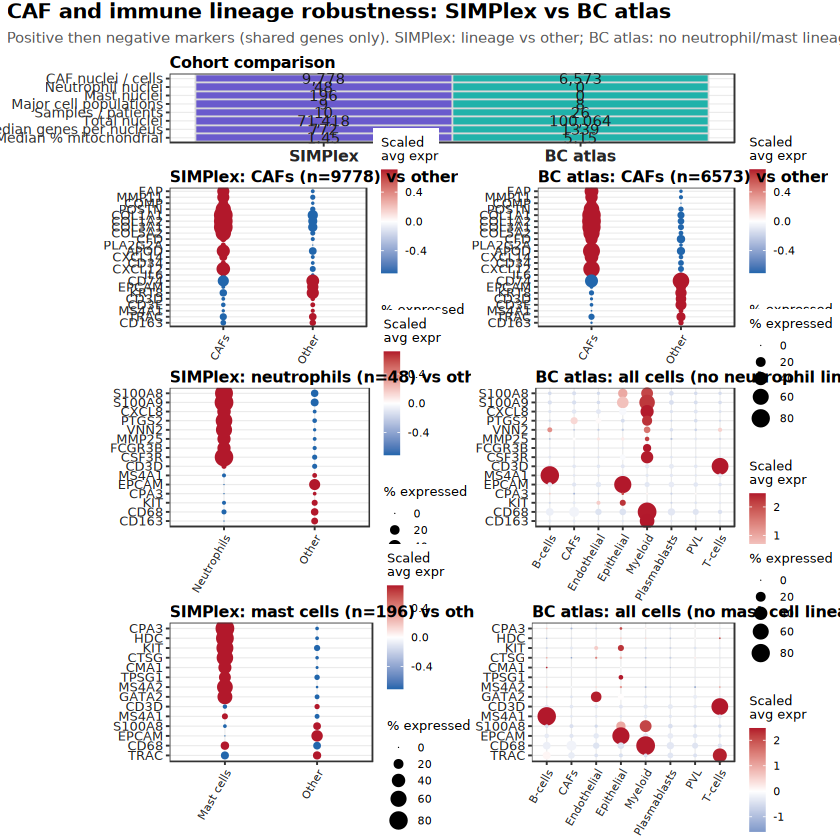

In [55]:
# === Plotting ===
theme_compact <- theme_bw(base_size = 9) +
  theme(
    plot.title = element_text(face = "bold", size = 9, margin = margin(b = 2)),
    plot.margin = margin(2, 2, 2, 2),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey92", linewidth = 0.25),
    legend.key.size = unit(0.3, "cm"),
    legend.text = element_text(size = 6.5),
    legend.title = element_text(size = 7.5),
    legend.box.spacing = unit(0.15, "cm")
  )

summary_long <- summary_df %>%
  pivot_longer(cols = c("SIMPlex", "BC_atlas"), names_to = "dataset", values_to = "value") %>%
  mutate(
    dataset = recode(dataset, BC_atlas = "BC atlas"),
    dataset = factor(dataset, levels = c("SIMPlex", "BC atlas")),
    label = if_else(
      metric %in% c("Median genes per nucleus", "Median % mitochondrial"),
      as.character(value),
      format(round(value), big.mark = ",", trim = TRUE)
    )
  )

p_summary <- ggplot(summary_long, aes(x = dataset, y = metric, fill = dataset)) +
  geom_tile(colour = "grey85", linewidth = 0.35) +
  geom_text(aes(label = label), size = 3.1, colour = "grey10") +
  scale_fill_manual(values = c("SIMPlex" = COLS_ASSAYS[1], "BC atlas" = COLS_ASSAYS[3]), guide = "none") +
  scale_y_discrete(limits = rev(levels(summary_df$metric))) +
  labs(title = "Cohort comparison", x = NULL, y = NULL) +
  theme_compact +
  theme(
    axis.text.x = element_text(face = "bold", size = 9, colour = "grey15"),
    axis.text.y = element_text(size = 8, colour = "grey20"),
    panel.grid = element_blank(),
    plot.margin = margin(2, 4, 2, 6)
  )

# DotPlot stats (matrix-indexed; genes restricted to genes_both in prep)
dotplot_seurat <- function(obj, groups, features, title) {
  assay <- DefaultAssay(obj)
  mat <- GetAssayData(obj, assay = assay, layer = "data")
  n <- ncol(obj)
  groups <- groups[seq_len(n)]
  feats <- intersect(features, genes_both)
  feats <- feats[feats %in% rownames(mat)]
  if (length(feats) == 0) stop("No shared marker genes found for: ", title)

  dp <- bind_rows(lapply(feats, function(gene) {
    idx <- match(gene, rownames(mat))
    x <- as.numeric(mat[idx, seq_len(n)])
    tibble(
      features.plot = gene,
      id = groups,
      avg.exp = ave(x, groups, FUN = mean),
      pct.exp = 100 * ave(x > 0, groups, FUN = mean)
    ) %>% distinct(id, .keep_all = TRUE)
  })) %>%
    group_by(features.plot) %>%
    mutate(avg.exp.scaled = as.numeric(scale(avg.exp))) %>%
    ungroup() %>%
    mutate(
      features.plot = factor(features.plot, levels = rev(feats)),
      id = factor(id, levels = levels(groups))
    )

  ggplot(dp, aes(x = features.plot, y = id)) +
    geom_point(aes(size = pct.exp, colour = avg.exp.scaled), stroke = 0) +
    scale_color_gradient2(
      low = "#2166AC", mid = "white", high = "#B2182B",
      midpoint = 0, name = "Scaled\navg expr"
    ) +
    scale_size_continuous(range = c(0.1, 5), name = "% expressed") +
    guides(
      colour = guide_colorbar(barheight = unit(2.2, "cm"), barwidth = unit(0.35, "cm")),
      size = guide_legend(keyheight = unit(0.35, "cm"))
    ) +
    coord_flip() +
    labs(title = title, x = NULL, y = NULL) +
    theme_compact +
    theme(
      axis.text.x = element_text(angle = 60, hjust = 1, size = 6.5, colour = "grey15"),
      axis.text.y = element_text(size = 7.5, colour = "grey15"),
      legend.position = "right",
      legend.box = "vertical"
    )
}

plots <- lapply(plot_specs, function(s) {
  dotplot_seurat(s$obj, s$group, s$features, s$title)
})
p_caf_simp  <- plots[[1]]
p_caf_atlas <- plots[[2]]
p_neut_simp <- plots[[3]]
p_neut_atlas <- plots[[4]]
p_mast_simp <- plots[[5]]
p_mast_atlas <- plots[[6]]

panel_val <- p_summary /
  (p_caf_simp | p_caf_atlas) /
  (p_neut_simp | p_neut_atlas) /
  (p_mast_simp | p_mast_atlas) +
  plot_annotation(
    title = "CAF and immune lineage robustness: SIMPlex vs BC atlas",
    subtitle = "Positive then negative markers (shared genes only). SIMPlex: lineage vs other; BC atlas: no neutrophil/mast lineage — all major types shown.",
    theme = theme(
      plot.title = element_text(face = "bold", size = 12, hjust = 0),
      plot.subtitle = element_text(size = 8.5, colour = "grey35", hjust = 0, margin = margin(b = 4))
    )
  ) +
  plot_layout(heights = c(0.5, 1, 1, 1), guides = "keep") &
  theme(plot.margin = margin(2, 2, 2, 2))

panel_val

ggsave(file.path(wd_val, "CAF_validation_composite.pdf"), panel_val, width = 8.5, height = 14, limitsize = FALSE)
ggsave(file.path(wd_val, "CAF_validation_composite.png"), panel_val, width = 8.5, height = 14, dpi = 300, limitsize = FALSE)


## Spearman co-localization threshold — sensitivity analysis

Per-`sample_id` threshold sweep (0–0.4, step 0.005) with three summary panels:
1. Empirical distribution of pairwise Spearman ρ (where r = 0.15 falls in the data)
2. ARI of Louvain partition at each threshold **T** vs partition at **r = 0.15** (ARI = 1 at T = 0.15 by definition)
3. Cohort-mean edge count, cluster count, and median cluster size (network size)

In [ ]:
mergedVis <- readRDS(file.path(SPATIAL_RDS, "breast_cancer/cross_patient/VISIUM_breast_allSamples.rds"))

In [45]:
library(igraph)
set.seed(1)

wd_sens <- file.path(FIGS_ROOT, "review", "correlation_threshold_sensitivity")
dir.create(wd_sens, recursive = TRUE, showWarnings = FALSE)

cor_thr <- 0.15  # reference partition for ARI panel and diagnostic table
thr_grid <- seq(0, 0.4, by = 0.005)
thr_grid_net <- seq(0, 0.4, by = 0.05)  # sparser grid for network PNGs only

# One spatial object per sample_id (no pooled cross-patient correlation)
samples <- sort(unique(mergedVis$sample_id))
spls <- setNames(lapply(samples, function(s) {
  spl <- SubsetSTData(mergedVis, expression = sample_id == !!s)
  stopifnot(length(unique(spl$sample_id)) == 1L, unique(spl$sample_id) == s)
  spl
}), samples)

cat("Per-sample subsets:\n")
print(table(mergedVis$sample_id))
cat("Subpopulations in network (spots with signal > 0), per sample:\n")
print(sapply(spls, function(spl) {
  DefaultAssay(spl) <- "subpopulation"
  d <- FetchData(spl, rownames(spl))
  sum(colSums(d > 0, na.rm = TRUE) > 0)
}))

theme_compact <- theme_bw(base_size = 9) +
  theme(
    plot.title = element_text(face = "bold", size = 9, margin = margin(b = 2)),
    plot.margin = margin(2, 2, 2, 2),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey92", linewidth = 0.25),
    legend.key.size = unit(0.3, "cm"),
    legend.text = element_text(size = 6.5),
    legend.title = element_text(size = 7.5),
    legend.box.spacing = unit(0.15, "cm")
  )

get_cor_matrix <- function(spl) {
  stopifnot(length(unique(spl$sample_id)) == 1L)
  DefaultAssay(spl) <- "subpopulation"
  data <- FetchData(spl, rownames(spl)) %>%
    as.data.frame() %>%
    select(where(~ sum(., na.rm = TRUE) > 0))
  nodes <- colnames(data)
  cor_mat <- cor(data, method = "spearman", use = "pairwise.complete.obs")
  diag(cor_mat) <- NA
  rownames(cor_mat) <- colnames(cor_mat) <- nodes
  cor_mat
}

network_at_thr <- function(cor_mat, thr) {
  nodes <- colnames(cor_mat)
  stopifnot(!is.null(nodes), length(nodes) == nrow(cor_mat))
  cor_net <- t(cor_mat)
  cor_net[cor_net < thr] <- 0
  net <- graph_from_adjacency_matrix(cor_net, weighted = TRUE, mode = "undirected", diag = FALSE)
  set.seed(1)
  cl <- cluster_louvain(net)
  memb <- as.integer(membership(cl))
  stopifnot(length(memb) == length(nodes))
  names(memb) <- nodes
  cluster_sizes <- as.integer(table(memb))
  list(
    network = net,
    membership = memb,
    n_edges = ecount(net),
    n_components = components(net)$no,
    n_clusters = length(cluster_sizes),
    mean_cluster_size = mean(cluster_sizes),
    median_cluster_size = median(cluster_sizes)
  )
}

partition_ari <- function(x, y) {
  stopifnot(length(x) == length(y), length(x) >= 2L)
  if (requireNamespace("mclust", quietly = TRUE)) {
    return(mclust::adjustedRandIndex(as.integer(x), as.integer(y)))
  }
  x <- as.integer(factor(x))
  y <- as.integer(factor(y))
  tab <- table(x, y)
  comb2 <- function(n) {
    n <- as.numeric(n)
    ifelse(n < 2, 0, n * (n - 1) / 2)
  }
  a <- sum(comb2(tab))
  b <- sum(comb2(rowSums(tab)))
  c <- sum(comb2(colSums(tab)))
  n <- sum(tab)
  d <- comb2(n)
  denom <- (b + c) / 2 - b * c / d
  if (!is.finite(denom) || denom == 0) {
    return(as.numeric(length(unique(x)) == 1L && length(unique(y)) == 1L))
  }
  (a - b * c / d) / denom
}

aligned_partition_ari <- function(memb_ref, memb_alt, nodes) {
  x <- as.integer(memb_ref[nodes])
  y <- as.integer(memb_alt[nodes])
  stopifnot(!any(is.na(x)), !any(is.na(y)))
  partition_ari(x, y)
}

cor_mats <- lapply(spls, get_cor_matrix)
names(cor_mats) <- names(spls)

net_at_ref <- lapply(cor_mats, function(cor_mat) network_at_thr(cor_mat, cor_thr))
per_sample_ref <- data.frame(
  sample = names(spls),
  n_subpopulations = vapply(cor_mats, nrow, integer(1)),
  n_edges = vapply(net_at_ref, function(x) as.integer(x$n_edges), integer(1)),
  n_clusters = vapply(net_at_ref, function(x) as.integer(x$n_clusters), integer(1)),
  n_components = vapply(net_at_ref, function(x) as.integer(x$n_components), integer(1))
)
cat("Per-sample network at r =", cor_thr, ":\n")
print(per_sample_ref)

cor_long <- do.call(rbind, lapply(names(cor_mats), function(sample) {
  vals <- cor_mats[[sample]][upper.tri(cor_mats[[sample]]) & !is.na(cor_mats[[sample]])]
  data.frame(sample = sample, rho = vals)
}))

ref_by_sample <- lapply(cor_mats, function(cor_mat) network_at_thr(cor_mat, cor_thr))

sens_df <- do.call(rbind, lapply(names(cor_mats), function(sample) {
  cor_mat <- cor_mats[[sample]]
  nodes <- colnames(cor_mat)
  ref_memb <- ref_by_sample[[sample]]$membership
  net_by_thr <- lapply(thr_grid, function(thr) network_at_thr(cor_mat, thr))
  do.call(rbind, lapply(seq_along(thr_grid), function(i) {
    thr <- thr_grid[i]
    net_info <- net_by_thr[[i]]
    data.frame(
      sample = sample,
      threshold = thr,
      ari = aligned_partition_ari(ref_memb, net_info$membership, nodes),
      n_edges = net_info$n_edges,
      n_clusters = net_info$n_clusters,
      mean_cluster_size = net_info$mean_cluster_size,
      median_cluster_size = net_info$median_cluster_size
    )
  }))
}))

sens_summary <- sens_df %>%
  group_by(threshold) %>%
  summarise(
    mean_ari = mean(ari), sd_ari = sd(ari),
    mean_n_edges = mean(n_edges), sd_n_edges = sd(n_edges),
    mean_n_clusters = mean(n_clusters), sd_n_clusters = sd(n_clusters),
    mean_mean_cluster_size = mean(mean_cluster_size), sd_mean_cluster_size = sd(mean_cluster_size),
    mean_median_cluster_size = mean(median_cluster_size), sd_median_cluster_size = sd(median_cluster_size),
    .groups = "drop"
  )

print(sens_summary)

write.csv(sens_df, file.path(wd_sens, "threshold_sensitivity_per_sample.csv"), row.names = FALSE)
write.csv(sens_summary, file.path(wd_sens, "threshold_sensitivity_summary.csv"), row.names = FALSE)

# One PNG per sample: all thresholds (lineage | Louvain per row)
wd_net <- file.path(wd_sens, "networks")
dir.create(wd_net, recursive = TRUE, showWarnings = FALSE)
pop_map <- int.all@meta.data %>%
  distinct(subpopulation, population) %>%
  mutate(subpopulation = gsub("_", "-", subpopulation)) %>%
  deframe()
ct_cols <- c(immune = "#3498DB", stromal = "#2ECC71", epithelial = "#E74C3C")
niche_cols <- setNames(scales::hue_pal()(30), as.character(1:30))

plot_network_panel <- function(net, vertex.color, main) {
  deg <- degree(net, mode = "all")
  plot(net, layout = layout_with_fr(net),
       vertex.size = pmax(deg * 2.2, 3), vertex.color = vertex.color,
       vertex.frame.color = "white", vertex.label.cex = 0.45,
       edge.width = pmin(E(net)$weight * 2.5, 4),
       edge.color = rgb(0.6, 0.6, 0.6, 0.3), main = main, cex.main = 0.75)
}

for (sample in names(cor_mats)) {
  cor_mat <- cor_mats[[sample]]
  n_thr <- length(thr_grid_net)
  png(file.path(wd_net, paste0(sample, "_networks.png")),
      width = 9, height = 2.1 * n_thr, units = "in", res = 150)
  par(mfrow = c(n_thr, 2), mar = c(0.5, 0.5, 2, 0.5), oma = c(0, 0, 3, 0))
  for (thr in thr_grid_net) {
    set.seed(1)
    net_info <- network_at_thr(cor_mat, thr)
    net <- net_info$network
    main <- sprintf("r = %.3f | edges = %d | clusters = %d", thr, net_info$n_edges, net_info$n_clusters)
    node_names <- V(net)$name
    ct_colors <- vapply(node_names, function(n) {
      ct <- pop_map[[gsub("_", "-", n)]]
      if (!is.null(ct) && ct %in% names(ct_cols)) ct_cols[[ct]] else "#BDC3C7"
    }, character(1))
    cl_colors <- niche_cols[as.character(net_info$membership)]
    plot_network_panel(net, ct_colors, paste(main, "| lineage"))
    plot_network_panel(net, cl_colors, paste(main, "| Louvain"))
  }
  mtext(sample, outer = TRUE, cex = 1.1, font = 2, line = 1)
  dev.off()
}
cat("Saved 1 PNG per sample under:", wd_net, "\n")

Per-sample subsets:

patient1_55um patient2_55um patient4_55um patient5_55um patient6_55um 
         4281          4653         14190          9732         12949 
patient7_55um patient8_55um patient9_55um 
        12838          4639         13062 
Subpopulations in network (spots with signal > 0), per sample:
patient1_55um patient2_55um patient4_55um patient5_55um patient6_55um 
           23            25            36            34            23 
patient7_55um patient8_55um patient9_55um 
           23            29            29 
Per-sample network at r = 0.15 :
                     sample n_subpopulations n_edges n_clusters n_components
patient1_55um patient1_55um               23      53          4            2
patient2_55um patient2_55um               25      73          4            3
patient4_55um patient4_55um               36      76          7            4
patient5_55um patient5_55um               34      83          8            6
patient6_55um patient6_55um               

Warning message:
“Removed 300 rows containing non-finite outside the scale range (`stat_ecdf()`).”
Warning message:
“Removed 300 rows containing non-finite outside the scale range (`stat_ecdf()`).”
Warning message:
“Removed 300 rows containing non-finite outside the scale range (`stat_ecdf()`).”
Warning message:
“Removed 300 rows containing non-finite outside the scale range (`stat_ecdf()`).”
Warning message:
“Removed 300 rows containing non-finite outside the scale range (`stat_ecdf()`).”
Warning message:
“Removed 300 rows containing non-finite outside the scale range (`stat_ecdf()`).”


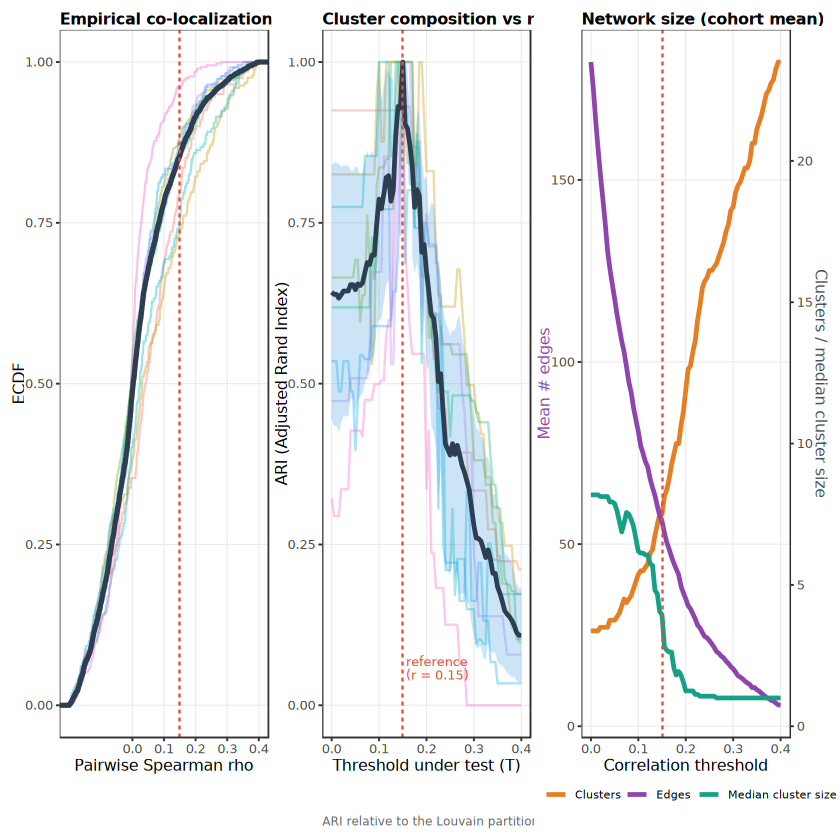

In [46]:
thr_vline <- geom_vline(
  xintercept = cor_thr, linetype = "dashed", colour = "#E74C3C", linewidth = 0.5
)
ref_label <- annotate(
  "text", x = cor_thr, y = 0.04, hjust = -0.05, vjust = 0,
  label = "reference\n(r = 0.15)", colour = "#E74C3C", size = 2.6, lineheight = 0.9
)

p_ecdf <- ggplot() +
  stat_ecdf(data = cor_long, aes(rho, colour = sample, group = sample), linewidth = 0.45, alpha = 0.4) +
  stat_ecdf(data = data.frame(rho = cor_long$rho), aes(rho), colour = "#2C3E50", linewidth = 1.1) +
  thr_vline +
  scale_x_continuous(limits = c(-0.2, 0.4), breaks = seq(0, 0.4, 0.1)) +
  labs(x = "Pairwise Spearman rho", y = "ECDF", title = "Empirical co-localization distribution") +
  theme_compact + theme(legend.position = "none")

p_ari <- ggplot(sens_df, aes(threshold, ari, colour = sample, group = sample)) +
  geom_line(alpha = 0.35, linewidth = 0.5) +
  geom_ribbon(
    data = sens_summary,
    aes(x = threshold, ymin = mean_ari - sd_ari, ymax = mean_ari + sd_ari),
    inherit.aes = FALSE, fill = "#3498DB", alpha = 0.25
  ) +
  geom_line(
    data = sens_summary, aes(x = threshold, y = mean_ari),
    inherit.aes = FALSE, colour = "#2C3E50", linewidth = 1
  ) +
  thr_vline +
  ref_label +
  scale_x_continuous(limits = c(0, 0.4), breaks = seq(0, 0.4, 0.1)) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(
    x = "Threshold under test (T)",
    y = "ARI (Adjusted Rand Index)",
    title = "Cluster composition vs r = 0.15 reference",
    caption = "ARI relative to the Louvain partition at r = 0.15"
  ) +
  theme_compact +
  theme(legend.position = "none", plot.caption = element_text(size = 7, colour = "grey40", hjust = 0))

right_max <- max(
  c(sens_summary$mean_n_clusters, sens_summary$mean_median_cluster_size),
  na.rm = TRUE
)
edge_scale <- max(sens_summary$mean_n_edges, na.rm = TRUE) / right_max

size_plot <- rbind(
  data.frame(
    threshold = sens_summary$threshold, metric = "Edges",
    y = sens_summary$mean_n_edges
  ),
  data.frame(
    threshold = sens_summary$threshold, metric = "Clusters",
    y = sens_summary$mean_n_clusters * edge_scale
  ),
  data.frame(
    threshold = sens_summary$threshold, metric = "Median cluster size",
    y = sens_summary$mean_median_cluster_size * edge_scale
  )
)

p_size <- ggplot(size_plot, aes(x = threshold, y = y, colour = metric)) +
  geom_line(linewidth = 1) +
  thr_vline +
  scale_x_continuous(limits = c(0, 0.4), breaks = seq(0, 0.4, 0.1)) +
  scale_colour_manual(
    values = c(
      "Edges" = "#8E44AD",
      "Clusters" = "#E67E22",
      "Median cluster size" = "#16A085"
    )
  ) +
  labs(
    x = "Correlation threshold",
    y = "Mean # edges",
    colour = NULL,
    title = "Network size (cohort mean)"
  ) +
  scale_y_continuous(
    sec.axis = sec_axis(~ . / edge_scale, name = "Clusters / median cluster size")
  ) +
  theme_compact +
  theme(
    axis.title.y = element_text(colour = "#8E44AD"),
    axis.title.y.right = element_text(colour = "grey30"),
    legend.position = "bottom",
    legend.key.width = unit(0.5, "cm"),
    legend.text = element_text(size = 6.5)
  )

panel_sens <- p_ecdf | p_ari | p_size +
  plot_annotation(
    title = "Sensitivity analysis of Spearman co-localization threshold",
    subtitle = "Per-sample spatial correlation networks",
    tag_levels = "A"
  )

ggsave(file.path(wd_sens, "correlation_threshold_sensitivity.pdf"), panel_sens, width = 12, height = 4, limitsize = FALSE)
ggsave(file.path(wd_sens, "correlation_threshold_sensitivity.png"), panel_sens, width = 12, height = 4, dpi = 300, limitsize = FALSE)
panel_sens

## SN Subpopulations Cluster Stability

Requires `int.all` loaded above and kernel **R (simplex renv)**. Run cells in order; outputs go to `figs/review/cluster_stability/`.

Each subsample is re-processed like `analysis_cellStateLevel`: **RNA counts → NormalizeData (log-normalized `data` layer) → HVG → Scale → PCA → Harmony(patient_ID) → FindClusters**. Do not use precomputed `harmony_subpop` or raw counts for graph building.

In [5]:
# scclusteval — installed in simplex renv (github::crazyhottommy/scclusteval)
stopifnot(requireNamespace("scclusteval", quietly = TRUE))
library(scclusteval)
packageVersion("scclusteval")

[1] ‘0.0.0.9000’

In [21]:
# Deposited object has `sample` but not `patient_ID` (added per-sample in analysis_majorLevel)
if (!("patient_ID" %in% colnames(int.all@meta.data))) {
  int.all <- AddMetaData(
    int.all,
    metadata = sub("_.*$", "", as.character(int.all$sample)),
    col.name = "patient_ID"
  )
}
stopifnot("patient_ID" %in% colnames(int.all@meta.data))
head(unique(int.all$patient_ID))

[1] "patient1" "patient2" "patient4" "patient5" "patient6" "patient7"

In [23]:
major_only <- c("Endothelial", "Adipocytes", "PVL")

best_jaccard_for_cluster <- function(ref_cells, sub_idents) {
  ref_in_sub <- intersect(ref_cells, names(sub_idents))
  if (length(ref_in_sub) == 0) return(NA_real_)
  sub_labels <- unique(unname(sub_idents[ref_in_sub]))
  max(vapply(sub_labels, function(lab) {
    lab_cells <- names(sub_idents)[sub_idents == lab]
    as.numeric(JaccardSets(ref_in_sub, lab_cells))
  }, numeric(1)), na.rm = TRUE)
}

# Match analysis_cellStateLevel: log-normalize RNA counts -> HVG -> scale -> PCA -> Harmony
ensure_patient_id <- function(obj) {
  if (!("sample" %in% colnames(obj@meta.data))) {
    stop("Metadata column 'sample' is required to derive patient_ID.")
  }
  if (!("patient_ID" %in% colnames(obj@meta.data))) {
    obj <- AddMetaData(
      obj,
      metadata = sub("_.*$", "", as.character(obj$sample)),
      col.name = "patient_ID"
    )
  }
  obj
}

preprocess_lineage <- function(obj, npcs = 30L) {
  obj <- ensure_patient_id(obj)
  stopifnot("patient_ID" %in% colnames(obj@meta.data))
  DefaultAssay(obj) <- "RNA"
  obj <- NormalizeData(obj, verbose = FALSE)
  obj <- FindVariableFeatures(obj, verbose = FALSE)
  obj <- ScaleData(obj, verbose = FALSE)
  obj <- RunPCA(obj, npcs = npcs, verbose = FALSE)
  RunHarmony(object = obj, group.by.vars = "patient_ID", theta = 0,
             plot_convergence = FALSE, verbose = FALSE)
}

# Major-level integration in analysis_majorLevel uses Harmony(sample)
preprocess_major <- function(obj, npcs = 30L) {
  stopifnot("sample" %in% colnames(obj@meta.data))
  DefaultAssay(obj) <- "RNA"
  obj <- NormalizeData(obj, verbose = FALSE)
  obj <- FindVariableFeatures(obj, verbose = FALSE)
  obj <- ScaleData(obj, verbose = FALSE)
  obj <- RunPCA(obj, npcs = npcs, verbose = FALSE)
  RunHarmony(object = obj, group.by.vars = "sample", theta = 0,
             plot_convergence = FALSE, verbose = FALSE)
}

# BC miniatlas: Harmony(Patient) only — no sample/patient_ID derivation
preprocess_bc_atlas <- function(obj, npcs = 30L) {
  stopifnot("Patient" %in% colnames(obj@meta.data))
  DefaultAssay(obj) <- "RNA"
  obj <- NormalizeData(obj, verbose = FALSE)
  obj <- FindVariableFeatures(obj, verbose = FALSE)
  obj <- ScaleData(obj, verbose = FALSE)
  obj <- RunPCA(obj, npcs = npcs, verbose = FALSE)
  RunHarmony(object = obj, group.by.vars = "Patient", theta = 0,
             plot_convergence = FALSE, verbose = FALSE)
}

run_subpop_stability <- function(obj,
                                 lineage_label,
                                 dims = 1:30,
                                 resolution = 0.8,
                                 n_iter = 20L,
                                 frac = 0.8,
                                 ident_col = "subpopulation",
                                 preprocess_fn = preprocess_lineage,
                                 seed = 1L) {
  Idents(obj) <- ident_col
  ref_idents <- unname(Idents(obj))
  names(ref_idents) <- colnames(obj)
  ref_levels <- sort(unique(ref_idents[!is.na(ref_idents)]))

  iter_scores <- lapply(seq_len(n_iter), function(i) {
    set.seed(seed + i)
    keep <- sample(colnames(obj), size = max(1L, floor(frac * ncol(obj))))
    sub <- subset(obj, cells = keep)
    sub <- preprocess_fn(sub)
    sub <- FindNeighbors(sub, reduction = "harmony", dims = dims, verbose = FALSE)
    sub <- FindClusters(sub, resolution = resolution, verbose = FALSE)
    sub_idents <- unname(Idents(sub))
    names(sub_idents) <- colnames(sub)
    vapply(ref_levels, function(cl) {
      best_jaccard_for_cluster(names(ref_idents)[ref_idents == cl], sub_idents)
    }, numeric(1))
  })

  score_mat <- do.call(cbind, iter_scores)
  rownames(score_mat) <- ref_levels

  out <- data.frame(
    label = ref_levels,
    lineage = lineage_label,
    n_cells = vapply(ref_levels, function(cl) sum(ref_idents == cl, na.rm = TRUE), integer(1)),
    median_jaccard = apply(score_mat, 1, median, na.rm = TRUE),
    mean_jaccard = apply(score_mat, 1, mean, na.rm = TRUE),
    n_iterations = n_iter,
    stable = apply(score_mat, 1, median, na.rm = TRUE) >= 0.6,
    highly_stable = apply(score_mat, 1, median, na.rm = TRUE) >= 0.85,
    stringsAsFactors = FALSE
  )
  names(out)[1] <- ident_col
  out
}

In [11]:
fine_subpops <- setdiff(unique(as.character(int.all$subpopulation)), major_only)
length(fine_subpops)

subset_lineage <- function(obj, label) {
  pop <- obj$population
  keep <- switch(
    label,
    CAF = pop == "CAFs",
    Epithelial = pop == "Epithelial",
    Immune = pop %in% c("T-cells", "B-cells", "Myeloid", "Plasmablasts"),
    stop("Unknown lineage: ", label)
  )
  subset(obj, cells = colnames(obj)[keep])
}

lineage_specs <- list(
  CAF = list(label = "CAF", resolution = 0.8),
  Epithelial = list(label = "Epithelial", resolution = 1.0),
  Immune = list(label = "Immune", resolution = 0.8)
)

stability_results <- lapply(lineage_specs, function(spec) {
  obj <- subset_lineage(int.all, spec$label)
  keep <- !is.na(obj$subpopulation) & obj$subpopulation %in% fine_subpops
  obj <- subset(obj, cells = colnames(obj)[keep])
  run_subpop_stability(obj, lineage_label = spec$label, resolution = spec$resolution)
})

stability_df <- bind_rows(stability_results) %>% arrange(lineage, desc(n_cells))
stability_df

[1] 53

Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50

,subpopulation,lineage,n_cells,median_jaccard,mean_jaccard,n_iterations,stable,highly_stable
,<fct>,<chr>,<int>,<dbl>,<dbl>,<int>,<lgl>,<lgl>
mCAF_plastic,mCAF_plastic,CAF,1887,0.42477144,0.40871918,20,FALSE,FALSE
iCAF_classical,iCAF_classical,CAF,1147,0.48704304,0.50048703,20,FALSE,FALSE
mCAF_classical,mCAF_classical,CAF,1126,0.77636493,0.69074827,20,TRUE,FALSE
apCAF_classical,apCAF_classical,CAF,355,0.73347684,0.73384546,20,TRUE,FALSE
iCAF_secretory,iCAF_secretory,CAF,346,0.80881780,0.80745418,20,TRUE,FALSE
mCAF_remodeling,mCAF_remodeling,CAF,248,0.34863251,0.39631109,20,FALSE,FALSE
ifnCAF_interferon,ifnCAF_interferon,CAF,246,0.70629987,0.55692375,20,TRUE,FALSE
apCAF_TcellMimicry,apCAF_TcellMimicry,CAF,233,0.68100852,0.67910699,20,TRUE,FALSE
vCAF,vCAF,CAF,111,0.73264605,0.67194920,20,TRUE,FALSE


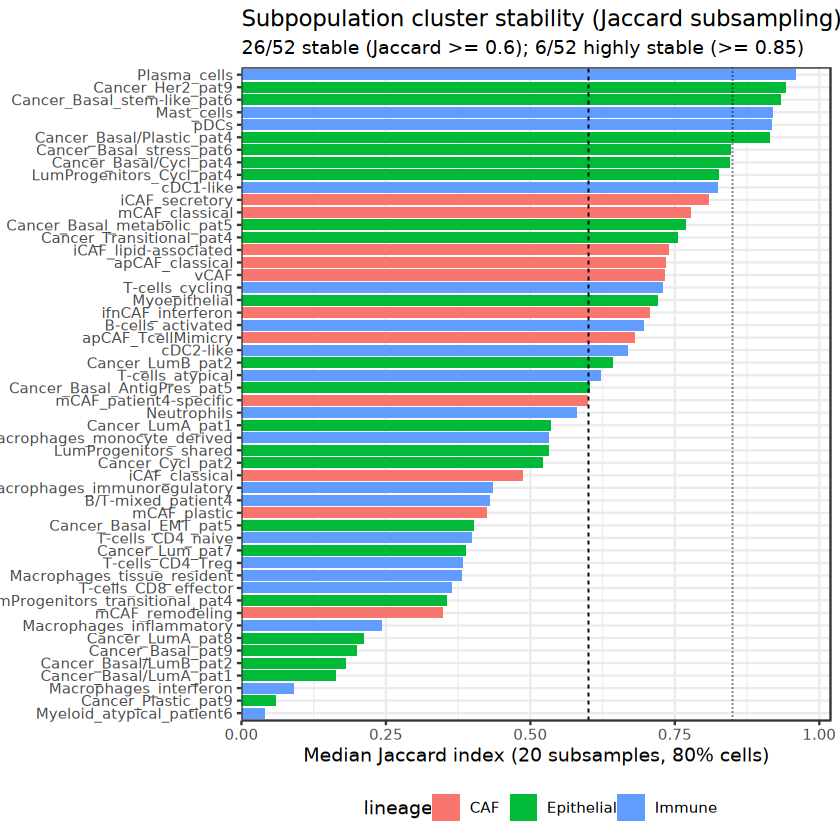

In [ ]:
wd_stab <- file.path(FIGS_ROOT, "review", "cluster_stability")
dir.create(wd_stab, recursive = TRUE, showWarnings = FALSE)

n_total <- nrow(stability_df)
n_stable <- sum(stability_df$stable, na.rm = TRUE)
n_high <- sum(stability_df$highly_stable, na.rm = TRUE)

write.csv(stability_df, file.path(wd_stab, "subpopulation_stability_summary.csv"), row.names = FALSE)

p_stab <- ggplot(stability_df, aes(x = reorder(subpopulation, median_jaccard), y = median_jaccard, fill = lineage)) +
  geom_col(width = 0.8) +
  geom_hline(yintercept = 0.6, linetype = "dashed", linewidth = 0.4) +
  geom_hline(yintercept = 0.85, linetype = "dotted", linewidth = 0.4) +
  coord_flip() +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.02))) +
  labs(
    title = "Subpopulation cluster stability (Jaccard subsampling)",
    subtitle = sprintf(
      "%d/%d stable (Jaccard >= 0.6); %d/%d highly stable (>= 0.85)",
      n_stable, n_total, n_high, n_total
    ),
    x = NULL,
    y = "Median Jaccard index (20 subsamples, 80% cells)"
  ) +
  theme_bw(base_size = 11) +
  theme(legend.position = "bottom")

ggsave(file.path(wd_stab, "subpopulation_jaccard_stability.pdf"), p_stab,
       width = 10, height = max(6, 0.22 * n_total), limitsize = FALSE)

writeLines(c(
  "Cluster stability validation (scclusteval; Tang et al., Bioinformatics 2020)",
  "",
  paste0(
    "For each lineage (CAFs, epithelial, immune), we subsampled 80% of nuclei in ",
    "20 iterations, re-clustered after lineage-specific preprocessing (NormalizeData ",
    "on RNA counts, HVG, scaling, PCA, Harmony on patient_ID), and computed Jaccard ",
    "similarity between each subpopulation and its best-matching subsample cluster."
  ),
  "",
  sprintf("%d/%d subpopulations had median Jaccard >= 0.6 (stable).", n_stable, n_total),
  sprintf("%d/%d subpopulations had median Jaccard >= 0.85 (highly stable).", n_high, n_total)
), file.path(wd_stab, "cluster_stability.txt"))

p_stab

### Major population stability

Same Jaccard subsampling workflow on **`population`** (major lineages) across the **full** integrated object. Uses `Harmony(sample)` to match [`analysis_majorLevel.ipynb`](analysis_majorLevel.ipynb). Expect long runtime (~71k nuclei × 20 subsamples).

In [14]:
length(unique(na.omit(int.all$population)))

pop_stability_df <- run_subpop_stability(
  obj = int.all,
  lineage_label = "major",
  ident_col = "population",
  preprocess_fn = preprocess_major,
  resolution = 0.8,
  n_iter = 20L
) %>% arrange(desc(n_cells))

pop_stability_df

[1] 9

Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 2856700)”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 2856700)”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 2856700)”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“N

,population,lineage,n_cells,median_jaccard,mean_jaccard,n_iterations,stable,highly_stable
,<fct>,<chr>,<int>,<dbl>,<dbl>,<int>,<lgl>,<lgl>
Epithelial,Epithelial,major,36977,0.1915952,0.1950997,20,FALSE,FALSE
CAFs,CAFs,major,9778,0.4400449,0.4399962,20,FALSE,FALSE
T-cells,T-cells,major,8099,0.5592488,0.5526920,20,FALSE,FALSE
Myeloid,Myeloid,major,7927,0.7305656,0.6992016,20,TRUE,FALSE
Endothelial,Endothelial,major,3137,0.6924711,0.6919061,20,TRUE,FALSE
Plasmablasts,Plasmablasts,major,1979,0.7269559,0.7219943,20,TRUE,FALSE
B-cells,B-cells,major,1872,0.4404163,0.4389005,20,FALSE,FALSE
PVL,PVL,major,1248,0.3618659,0.3612196,20,FALSE,FALSE
Adipocytes,Adipocytes,major,401,0.5061029,0.5042239,20,FALSE,FALSE


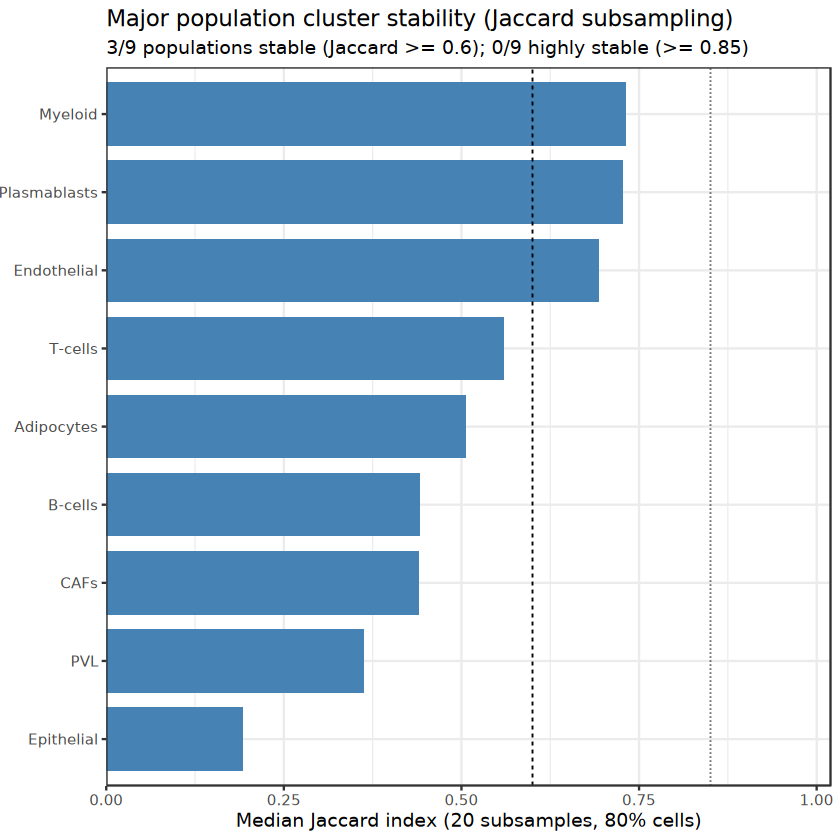

In [16]:
wd_stab <- file.path(FIGS_ROOT, "review", "cluster_stability")
dir.create(wd_stab, recursive = TRUE, showWarnings = FALSE)

n_pop <- nrow(pop_stability_df)
n_pop_stable <- sum(pop_stability_df$stable, na.rm = TRUE)
n_pop_high <- sum(pop_stability_df$highly_stable, na.rm = TRUE)

write.csv(pop_stability_df, file.path(wd_stab, "population_stability_summary.csv"), row.names = FALSE)

p_pop <- ggplot(pop_stability_df, aes(x = reorder(population, median_jaccard), y = median_jaccard)) +
  geom_col(width = 0.8, fill = "steelblue") +
  geom_hline(yintercept = 0.6, linetype = "dashed", linewidth = 0.4) +
  geom_hline(yintercept = 0.85, linetype = "dotted", linewidth = 0.4) +
  coord_flip() +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.02))) +
  labs(
    title = "Major population cluster stability (Jaccard subsampling)",
    subtitle = sprintf(
      "%d/%d populations stable (Jaccard >= 0.6); %d/%d highly stable (>= 0.85)",
      n_pop_stable, n_pop, n_pop_high, n_pop
    ),
    x = NULL,
    y = "Median Jaccard index (20 subsamples, 80% cells)"
  ) +
  theme_bw(base_size = 11)

ggsave(file.path(wd_stab, "population_jaccard_stability.pdf"), p_pop,
       width = 8, height = max(4, 0.35 * n_pop), limitsize = FALSE)
p_pop

In [25]:
# --- bc_atlas: Jaccard stability on BC miniatlas (major + minor) ---
# Uses bc_atlas$Patient for Harmony; no sample/patient_ID prep needed.
wd_stab <- file.path(FIGS_ROOT, "review", "cluster_stability")
dir.create(wd_stab, recursive = TRUE, showWarnings = FALSE)

bc_atlas <- readRDS(file.path(EXT_REFS, "BC_atlas/miniatlas.rds"))
bc_atlas <- UpdateSeuratObject(bc_atlas)
bc_atlas$celltype_major <- ifelse(
  bc_atlas$celltype_major %in% c("Normal Epithelial", "Cancer Epithelial"),
  "Epithelial", bc_atlas$celltype_major
)

bc_atlas_major <- run_subpop_stability(
  obj = bc_atlas,
  lineage_label = "bc_atlas_major",
  ident_col = "celltype_major",
  preprocess_fn = preprocess_bc_atlas,
  resolution = 0.8,
  n_iter = 20L
) %>%
  rename(label = celltype_major) %>%
  mutate(atlas_level = "major")

bc_atlas_minor <- run_subpop_stability(
  obj = bc_atlas,
  lineage_label = "bc_atlas_minor",
  ident_col = "celltype_minor",
  preprocess_fn = preprocess_bc_atlas,
  resolution = 1.0,
  n_iter = 20L
) %>%
  rename(label = celltype_minor) %>%
  mutate(atlas_level = "minor")

bc_atlas_stability_df <- bind_rows(bc_atlas_major, bc_atlas_minor) %>%
  select(atlas_level, label, lineage, n_cells, median_jaccard, mean_jaccard,
         n_iterations, stable, highly_stable) %>%
  arrange(atlas_level, desc(n_cells))

write.csv(
  bc_atlas_stability_df,
  file.path(wd_stab, "bc_atlas_stability_summary.csv"),
  row.names = FALSE
)

n_bc <- nrow(bc_atlas_stability_df)
n_bc_stable <- sum(bc_atlas_stability_df$stable, na.rm = TRUE)
n_bc_high <- sum(bc_atlas_stability_df$highly_stable, na.rm = TRUE)

p_bc_atlas <- ggplot(
  bc_atlas_stability_df,
  aes(x = reorder(label, median_jaccard), y = median_jaccard, fill = atlas_level)
) +
  geom_col(width = 0.8) +
  geom_hline(yintercept = 0.6, linetype = "dashed", linewidth = 0.4) +
  geom_hline(yintercept = 0.85, linetype = "dotted", linewidth = 0.4) +
  coord_flip() +
  facet_grid(atlas_level ~ ., scales = "free_y", space = "free_y") +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.02))) +
  labs(
    title = "BC atlas (miniatlas) cluster stability — major & minor",
    subtitle = sprintf(
      "%d/%d labels stable (Jaccard >= 0.6); %d/%d highly stable (>= 0.85)",
      n_bc_stable, n_bc, n_bc_high, n_bc
    ),
    x = NULL,
    y = "Median Jaccard index (20 subsamples, 80% cells)",
    fill = "Atlas level"
  ) +
  theme_bw(base_size = 11) +
  theme(legend.position = "none", strip.text = element_text(face = "bold"))

ggsave(
  file.path(wd_stab, "bc_atlas_jaccard_stability.pdf"),
  p_bc_atlas,
  width = 10,
  height = max(8, 0.25 * n_bc + 2),
  limitsize = FALSE
)

bc_atlas_stability_df

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘umap’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in pca

Updating slots in umap

Setting umap DimReduc to global

Setting assay used for NormalizeData.RNA to RNA

Setting assay used for FindVariableFeatures.RNA to RNA

Setting assay used for ScaleData.RNA to RNA

Setting assay used for RunPCA.RNA to RNA

Setting assay used for RunUMAP.RNA.pca to RNA

Validating object structure for Assay5 ‘RNA’

Validating object structure for DimReduc ‘pca’

Validating object structure for DimReduc ‘umap’

Object representation is consistent with the most current Seurat version

Warning message:
“Different features in new layer data than already exists for scale.data”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning me

,atlas_level,label,lineage,n_cells,median_jaccard,mean_jaccard,n_iterations,stable,highly_stable
,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,<int>,<lgl>,<lgl>
T-cells,major,T-cells,bc_atlas_major,35214,0.374238197,0.367770518,20,FALSE,FALSE
Epithelial,major,Epithelial,bc_atlas_major,28844,0.389950938,0.389549599,20,FALSE,FALSE
Myeloid,major,Myeloid,bc_atlas_major,9675,0.615240130,0.614404830,20,TRUE,FALSE
Endothelial,major,Endothelial,bc_atlas_major,7605,0.520485043,0.532784617,20,FALSE,FALSE
CAFs,major,CAFs,bc_atlas_major,6573,0.913940624,0.909489413,20,TRUE,TRUE
PVL,major,PVL,bc_atlas_major,5423,0.931297239,0.931643951,20,TRUE,TRUE
Plasmablasts...7,major,Plasmablasts,bc_atlas_major,3524,0.656800011,0.699715388,20,TRUE,FALSE
B-cells,major,B-cells,bc_atlas_major,3206,0.904049984,0.902873587,20,TRUE,TRUE
T cells CD4+,minor,T cells CD4+,bc_atlas_minor,19231,0.532578587,0.535185121,20,FALSE,FALSE


In [7]:
bc_atlas <- readRDS(file.path(EXT_REFS, "BC_atlas/miniatlas.rds"))
bc_atlas <- UpdateSeuratObject(bc_atlas)
bc_atlas$celltype_major <- ifelse(
  bc_atlas$celltype_major %in% c("Normal Epithelial", "Cancer Epithelial"),
  "Epithelial", bc_atlas$celltype_major
)

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘umap’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in pca

Updating slots in umap

Setting umap DimReduc to global

Setting assay used for NormalizeData.RNA to RNA

Setting assay used for FindVariableFeatures.RNA to RNA

Setting assay used for ScaleData.RNA to RNA

Setting assay used for RunPCA.RNA to RNA

Setting assay used for RunUMAP.RNA.pca to RNA

Validating object structure for Assay5 ‘RNA’

Validating object structure for DimReduc ‘pca’

Validating object structure for DimReduc ‘umap’

Object representation is consistent with the most current Seurat version



## Compare patient-matched scRNA vs SIMPlex snRNA for deconvolution

**Reviewer concern:** Section-matched snRNA may not improve deconvolution beyond (i) patient-matched scRNA from a public atlas or (ii) a broad multi-patient reference.

**Matched pair:** `patient5_55um` (SIMPlex section-matched nuclei) ↔ BC miniatlas `CID44971` (Wu et al. 2021).

Three lines of evidence on this pair:

1. **Reference coverage** — cell populations captured in section-matched SN but absent or rare in atlas scRNA.
2. **Molecular concordance** — even for the same patient, nuclear (SN) and cellular (SC) pseudobulks diverge; SN is closer to Visium (also nuclear RNA).
3. **Deconvolution fidelity** — on `patient5_55um` Visium, section-matched SN yields higher concordance with independent UCell marker modules than patient-matched SC or the full atlas.

### Pseudobulk Spearman concordance (evidence 2)

For each dataset we collapse all cells/spots into **one expression vector per gene**:

| Profile | Source | Assay | Aggregation |
|---------|--------|-------|-------------|
| SN (section) | Section-matched SIMPlex nuclei | `RNA` `data` | mean across nuclei |
| SC (patient) | Patient-matched BC atlas cells | `RNA` `data` | mean across cells |
| Visium | All spots on the section | `Spatial` `data` | mean across spots |
| SN (pooled) | All SIMPlex breast nuclei | `RNA` `data` | mean across nuclei |

Genes are restricted to the intersection across all three expression assays (~17k genes). **Spearman ρ** is computed between pseudobulk vectors (rank correlation; robust to scale differences between assays). The key comparison is **SN–Visium vs SC–Visium**: both references match the patient, but only SN shares Visium's nuclear RNA compartment.

Outputs → `figs/review/sn_vs_sc_deconv/`.

Reference sizes:
Section-matched SIMPlex SN         Patient SIMPlex SN 
                      7678                      14387 
  Patient-matched atlas SC    BC atlas (all patients) 
                      7986                     100064 

Pathology annotation proportions (granular):
# A tibble: 6 × 4
  reference            celltype       n  prop
  <chr>                <chr>      <int> <dbl>
1 Histopathology (H&E) Epithelial  3633 0.627
2 Histopathology (H&E) Immune       729 0.126
3 Histopathology (H&E) Stroma      1434 0.247
4 CTA                  Epithelial  3349 0.522
5 CTA                  Immune      2136 0.333
6 CTA                  Stroma       929 0.145


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Reference vs pathology composition (patient5_55um ↔ CID44971)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Reference vs pathology composition (patient5_55um ↔ CID44971)' in 'mbcsToSbcs': dot substituted for <86>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Reference vs pathology composition (patient5_55um ↔ CID44971)' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Reference vs pathology composition (patient5_55um ↔ CID44971)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Reference vs pathology composition (pati


SIMPlex subpopulations in section (top):
                  subpopulation n_sn
1   Cancer_Basal_AntigPres_pat5 1954
2         Cancer_Basal_EMT_pat5 1437
3                          <NA> 1343
4          T-cells_CD8_effector  456
5   Cancer_Basal_metabolic_pat5  358
6              T-cells_atypical  353
7  Macrophages_immunoregulatory  281
8                   Endothelial  201
9                iCAF_classical  199
10                          PVL  140
11            B-cells_activated  118
12 Macrophages_monocyte_derived  103

Atlas minor types in matched patient (top):
        celltype_minor n_sc
1         T cells CD4+ 2247
2         T cells CD8+ 1711
3      Cancer Basal SC  646
4  Luminal Progenitors  442
5   CAFs MSC iCAF-like  421
6           Macrophage  316
7       B cells Memory  273
8      Cycling T-cells  271
9       Cancer Cycling  246
10      Mature Luminal  169
11                 DCs  167
12     CAFs myCAF-like  161


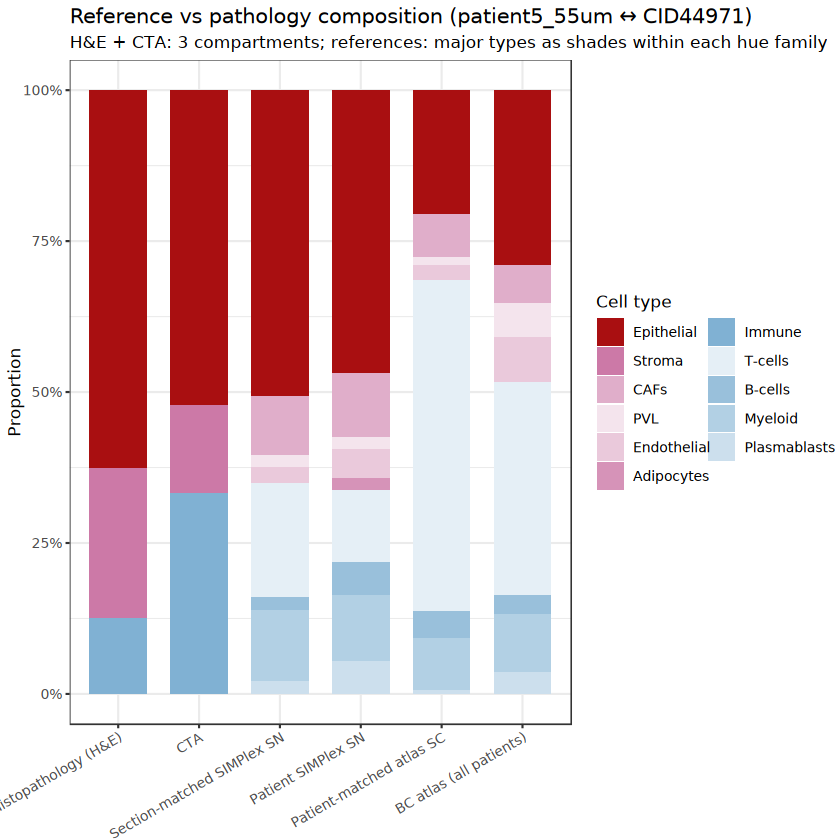

In [19]:
# === Setup: matched patient5 pair ===
wd_snsc <- file.path(FIGS_ROOT, "review", "sn_vs_sc_deconv")
dir.create(wd_snsc, recursive = TRUE, showWarnings = FALSE)

SAMPLE <- "patient5_55um"
ATLAS_PATIENT <- "CID44971"

stopifnot(exists("int.all"), exists("bc_atlas"))

if (!"percent.mt" %in% colnames(bc_atlas@meta.data)) {
  bc_atlas[["percent.mt"]] <- PercentageFeatureSet(bc_atlas, pattern = "^MT-")
}
if (!"patient_ID" %in% colnames(int.all@meta.data)) {
  int.all$patient_ID <- sub("_.*$", "", as.character(int.all$sample))
}

sn_ident <- if ("seuratAnnotation_major" %in% colnames(int.all@meta.data)) {
  "seuratAnnotation_major"
} else {
  "population"
}
sc_ident <- "celltype_major"

get_data_mat <- function(obj, assay = "RNA") {
  DefaultAssay(obj) <- assay
  tryCatch(LayerData(obj, layer = "data"), error = function(e) GetAssayData(obj, slot = "data"))
}

feature_names <- function(obj, assay = "RNA") rownames(obj[[assay]])

pseudobulk <- function(obj, assay = "RNA", cells = NULL) {
  mat <- get_data_mat(obj, assay)
  if (!is.null(cells)) mat <- mat[, cells, drop = FALSE]
  Matrix::rowMeans(mat)
}

major_order <- c(
  "Epithelial", "CAFs", "T-cells", "B-cells", "Myeloid",
  "Endothelial", "PVL", "Plasmablasts", "Adipocytes"
)

refs <- list(
  "Section-matched SIMPlex SN" = subset(int.all, subset = sample == SAMPLE),
  "Patient SIMPlex SN" = subset(int.all, subset = patient_ID == "patient5"),
  "Patient-matched atlas SC" = subset(bc_atlas, subset = Patient == ATLAS_PATIENT),
  "BC atlas (all patients)" = bc_atlas
)

cat("Reference sizes:\n")
print(sapply(refs, ncol))

# --- 1. Reference composition ---
comp_df <- bind_rows(lapply(names(refs), function(nm) {
  obj <- refs[[nm]]
  col <- if (grepl("SC|atlas", nm)) sc_ident else sn_ident
  tb <- table(obj@meta.data[[col]], useNA = "no")
  tibble(reference = nm, celltype = names(tb), n = as.integer(tb))
})) %>%
  mutate(
    celltype = gsub("_", "-", celltype),
    reference = factor(reference, levels = names(refs))
  ) %>%
  group_by(reference) %>%
  mutate(prop = n / sum(n))

# --- Pathology spot annotations: H&E histopathology + CTA (both when available) ---
load_histopath_simplified <- function(sample, spot_barcodes) {
  get_col <- function(type) {
    csv_path <- file.path(HISTO_DIR, sample, paste0(type, ".csv"))
    out <- setNames(rep(NA_character_, length(spot_barcodes)), spot_barcodes)
    if (!file.exists(csv_path)) return(out)
    df <- read.csv(csv_path)
    rownames(df) <- df$Barcode
    idx <- intersect(spot_barcodes, rownames(df))
    vals <- df[idx, 2]
    vals[vals == ""] <- NA
    out[idx] <- as.character(vals)
    out
  }

  epithelial <- get_col("epithelial")
  stroma <- get_col("stroma")
  immune <- get_col("immune")

  epithelial_simp <- ifelse(!is.na(epithelial), "epithelial", NA_character_)
  stroma_simp <- ifelse(!is.na(stroma), "stroma", NA_character_)
  immune_simp <- ifelse(!is.na(immune), "immune", NA_character_)

  stroma_f <- ifelse(!is.na(stroma_simp) & is.na(epithelial), stroma_simp, NA_character_)
  immune_f <- ifelse(!is.na(immune_simp) & is.na(stroma_simp), immune_simp, NA_character_)

  ifelse(
    !is.na(epithelial_simp), "Epithelial",
    ifelse(!is.na(stroma_f), "Stroma", ifelse(!is.na(immune_f), "Immune", NA_character_))
  )
}

load_cta_simplified <- function(sample, spot_barcodes) {
  cta_path <- file.path(CTA_DIR, paste0(sample, ".csv"))
  if (!file.exists(cta_path)) return(NULL)
  annot <- read.csv(cta_path)
  rownames(annot) <- annot$cellid
  annot <- annot[intersect(spot_barcodes, rownames(annot)), , drop = FALSE]
  if (nrow(annot) == 0) return(NULL)

  scores <- cbind(
    Epithelial = annot$tumor_per + annot$normal_gland_per,
    Immune = annot$immune_per,
    Stroma = annot$stroma_per
  )
  colnames(scores)[max.col(scores, ties.method = "first")]
}

labels_to_comp <- function(labels, reference_name) {
  if (is.null(labels) || length(labels) == 0 || !any(!is.na(labels))) return(NULL)
  tb <- table(labels, useNA = "no")
  tibble(reference = reference_name, celltype = names(tb), n = as.integer(tb)) %>%
    mutate(prop = n / sum(n))
}

cta_path <- file.path(CTA_DIR, paste0(SAMPLE, ".csv"))
spot_barcodes <- unique(c(
  if (file.exists(cta_path)) read.csv(cta_path)$cellid else character(0),
  if (exists("mergedVis")) rownames(mergedVis@meta.data)[mergedVis$sample_id == SAMPLE] else character(0)
))

path_dfs <- list(
  labels_to_comp(
    if (length(spot_barcodes) > 0) load_histopath_simplified(SAMPLE, spot_barcodes) else NULL,
    "Histopathology (H&E)"
  ),
  labels_to_comp(
    if (length(spot_barcodes) > 0) load_cta_simplified(SAMPLE, spot_barcodes) else NULL,
    "CTA"
  )
)
path_dfs <- path_dfs[!vapply(path_dfs, is.null, logical(1))]

if (length(path_dfs) > 0) {
  comp_df <- bind_rows(
    comp_df %>% mutate(reference = as.character(reference)),
    bind_rows(path_dfs)
  )
  cat("\nPathology annotation proportions (granular):\n")
  print(bind_rows(path_dfs) %>% select(reference, celltype, n, prop))
} else {
  comp_df <- comp_df %>% mutate(reference = as.character(reference))
  warning("No pathology annotations found for ", SAMPLE, " (checked HISTO_DIR and CTA_DIR).")
}

# Compartment hues shared with H&E + CTA; references keep granular cell types as shades
compartment_map <- c(
  Epithelial = "Epithelial",
  Stroma = "Stroma",
  Immune = "Immune",
  CAFs = "Stroma",
  PVL = "Stroma",
  Endothelial = "Stroma",
  Adipocytes = "Stroma",
  `T-cells` = "Immune",
  `B-cells` = "Immune",
  Myeloid = "Immune",
  Plasmablasts = "Immune"
)
compartment_levels <- c("Epithelial", "Stroma", "Immune")
compartment_cols <- c(Epithelial = "#a90f11", Stroma = "#CC79A7", Immune = "#80B1D3")

compartment_type_cols <- function(types, compartment_map, base_cols) {
  types <- unique(types)
  out <- setNames(rep(NA_character_, length(types)), types)
  for (comp in names(base_cols)) {
    in_comp <- types[compartment_map[types] == comp | types == comp]
    in_comp <- intersect(types, unique(in_comp))
    if (length(in_comp) == 0) next
    coarse <- intersect(in_comp, comp)
    detailed <- sort(setdiff(in_comp, comp))
    if (length(coarse) > 0) out[coarse] <- base_cols[comp]
    if (length(detailed) > 0) {
      shades <- grDevices::colorRampPalette(c(base_cols[comp], "#FFFFFF"))(length(detailed) + 2L)[2:(length(detailed) + 1L)]
      out[detailed] <- shades
    }
  }
  out[types]
}

celltype_levels <- c(
  "Epithelial",
  "Stroma", "CAFs", "PVL", "Endothelial", "Adipocytes",
  "Immune", "T-cells", "B-cells", "Myeloid", "Plasmablasts"
)

comp_df_granular <- comp_df %>%
  mutate(compartment = unname(compartment_map[celltype])) %>%
  filter(!is.na(compartment))

unmapped <- setdiff(unique(comp_df$celltype), names(compartment_map))
if (length(unmapped) > 0) {
  warning("Cell types omitted from plot (no compartment mapping): ", paste(unmapped, collapse = ", "))
}

path_first <- c("Histopathology (H&E)", "CTA")
ref_levels <- c(
  path_first[path_first %in% unique(comp_df_granular$reference)],
  names(refs)
)

present_types <- unique(comp_df_granular$celltype)
celltype_levels <- c(intersect(celltype_levels, present_types), setdiff(present_types, celltype_levels))
type_cols <- compartment_type_cols(present_types, compartment_map, compartment_cols)

comp_df_granular <- comp_df_granular %>%
  mutate(
    reference = factor(reference, levels = ref_levels),
    celltype = factor(celltype, levels = celltype_levels)
  )

comp_df <- comp_df_granular %>%
  group_by(reference, compartment) %>%
  summarise(prop = sum(prop), .groups = "drop") %>%
  mutate(compartment = factor(compartment, levels = compartment_levels))

comp_wide_granular <- comp_df_granular %>%
  select(reference, celltype, compartment, prop) %>%
  pivot_wider(names_from = celltype, values_from = prop, values_fill = 0)
write.csv(comp_wide_granular, file.path(wd_snsc, "reference_composition_granular.csv"), row.names = FALSE)

comp_wide <- comp_df %>%
  select(reference, compartment, prop) %>%
  pivot_wider(names_from = compartment, values_from = prop, values_fill = 0)
write.csv(comp_wide, file.path(wd_snsc, "reference_composition_compartments.csv"), row.names = FALSE)

p_comp <- ggplot(comp_df_granular, aes(x = reference, y = prop, fill = celltype)) +
  geom_col(position = "stack", width = 0.7) +
  scale_fill_manual(
    values = type_cols,
    breaks = celltype_levels,
    drop = FALSE,
    guide = guide_legend(ncol = 2, title = "Cell type")
  ) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = paste0("Reference vs pathology composition (", SAMPLE, " ↔ ", ATLAS_PATIENT, ")"),
    subtitle = "H&E + CTA: 3 compartments; references: major types as shades within each hue family",
    x = NULL, y = "Proportion"
  ) +
  theme_bw(base_size = 10) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

ggsave(
  file.path(wd_snsc, "reference_composition.pdf"),
  p_comp,
  width = max(9, 1.6 * length(unique(comp_df_granular$reference))),
  height = 5.5
)
print(p_comp)

# Highlight rare / missing lineages in atlas SC
sn_subpops <- int.all@meta.data %>%
  filter(sample == SAMPLE) %>%
  count(subpopulation, name = "n_sn") %>%
  arrange(desc(n_sn))
atlas_sub <- bc_atlas@meta.data %>%
  filter(Patient == ATLAS_PATIENT) %>%
  count(celltype_minor, name = "n_sc") %>%
  arrange(desc(n_sc))

cat("\nSIMPlex subpopulations in section (top):\n")
print(head(sn_subpops, 12))
cat("\nAtlas minor types in matched patient (top):\n")
print(head(atlas_sub, 12))

Shared genes for pseudobulk concordance: 16706 

Pseudobulk Spearman correlation matrix (16706 shared genes):
           SN_section SC_patient Visium SN_pooled
SN_section      1.000      0.771  0.928     0.947
SC_patient      0.771      1.000  0.827     0.779
Visium          0.928      0.827  1.000     0.908
SN_pooled       0.947      0.779  0.908     1.000

Key comparison — concordance with Visium:
# A tibble: 2 × 2
  comparison            spearman
  <chr>                    <dbl>
1 SN section <-> Visium    0.928
2 Patient SC <-> Visium    0.827


Warning message:
“Computation failed in `stat_binhex()`.
Caused by error in `compute_group()` at ggplot2/R/ggproto.R:197:17:
! The package "hexbin" is required for `stat_bin_hex()`.”
Warning message:
“Computation failed in `stat_binhex()`.
Caused by error in `compute_group()` at ggplot2/R/ggproto.R:197:17:
! The package "hexbin" is required for `stat_bin_hex()`.”
Warning message:
“Computation failed in `stat_binhex()`.
Caused by error in `compute_group()` at ggplot2/R/ggproto.R:197:17:
! The package "hexbin" is required for `stat_bin_hex()`.”
Warning message:
“Computation failed in `stat_binhex()`.
Caused by error in `compute_group()` at ggplot2/R/ggproto.R:197:17:
! The package "hexbin" is required for `stat_bin_hex()`.”
Warning message:
“Computation failed in `stat_binhex()`.
Caused by error in `compute_group()` at ggplot2/R/ggproto.R:197:17:
! The package "hexbin" is required for `stat_bin_hex()`.”
Warning message:
“Computation failed in `stat_binhex()`.
Caused by error in `compute_

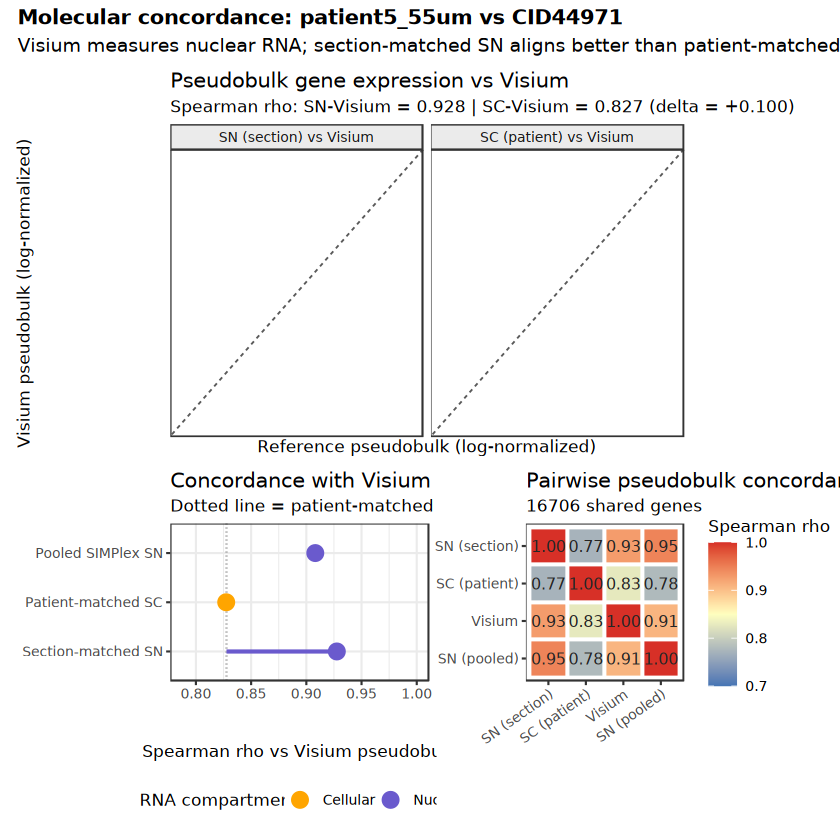

In [24]:
# --- 2. SN vs SC molecular concordance (same patient) ---
vis_p5_path <- file.path(SPATIAL_RDS, "breast_cancer/55um", SAMPLE, paste0(SAMPLE, "_3decon.rds"))
if (file.exists(vis_p5_path)) {
  vis_p5 <- readRDS(vis_p5_path)
} else if (exists("mergedVis")) {
  vis_p5 <- SubsetSTData(mergedVis, expression = sample_id == SAMPLE)
} else {
  mergedVis <- readRDS(file.path(SPATIAL_RDS, "breast_cancer/cross_patient/VISIUM_breast_allSamples.rds"))
  vis_p5 <- SubsetSTData(mergedVis, expression = sample_id == SAMPLE)
}
stopifnot(ncol(vis_p5) > 0)

vis_assay <- if ("Spatial" %in% Assays(vis_p5)) "Spatial" else DefaultAssay(vis_p5)

genes_shared <- Reduce(
  intersect,
  list(
    feature_names(refs[[1]], "RNA"),
    feature_names(refs[[3]], "RNA"),
    feature_names(vis_p5, vis_assay)
  )
)
cat("Shared genes for pseudobulk concordance:", length(genes_shared), "\n")
stopifnot(length(genes_shared) > 0)

pb_sn <- pseudobulk(refs[[1]])
pb_sc <- pseudobulk(refs[[3]])
pb_vis <- pseudobulk(vis_p5, assay = vis_assay)
pb_pooled <- pseudobulk(int.all)

profile_labels <- c(
  SN_section = "SN (section)",
  SC_patient = "SC (patient)",
  Visium = "Visium",
  SN_pooled = "SN (pooled)"
)

pb_profiles <- cbind(
  SN_section = pb_sn[genes_shared],
  SC_patient = pb_sc[genes_shared],
  Visium = pb_vis[genes_shared],
  SN_pooled = pb_pooled[genes_shared]
)

cor_mat <- cor(pb_profiles, method = "spearman", use = "pairwise.complete.obs")

cor_pairs <- tibble(
  comparison = c(
    "SN section <-> patient SC",
    "SN section <-> Visium",
    "Patient SC <-> Visium",
    "SN section <-> pooled SIMPlex"
  ),
  spearman = c(
    cor_mat["SN_section", "SC_patient"],
    cor_mat["SN_section", "Visium"],
    cor_mat["SC_patient", "Visium"],
    cor_mat["SN_section", "SN_pooled"]
  )
)
write.csv(cor_mat, file.path(wd_snsc, "pseudobulk_correlation_matrix.csv"), row.names = TRUE)
write.csv(cor_pairs, file.path(wd_snsc, "pseudobulk_spearman.csv"), row.names = FALSE)

cat("\nPseudobulk Spearman correlation matrix (", length(genes_shared), " shared genes):\n", sep = "")
print(round(cor_mat, 3))
cat("\nKey comparison — concordance with Visium:\n")
print(cor_pairs %>% filter(grepl("Visium", comparison)))

# --- Panel A: gene-level scatter vs Visium (the comparisons that matter) ---
rho_sn_vis <- cor_mat["SN_section", "Visium"]
rho_sc_vis <- cor_mat["SC_patient", "Visium"]

scatter_df <- bind_rows(
  tibble(
    gene = genes_shared,
    reference = pb_profiles[, "SN_section"],
    visium = pb_profiles[, "Visium"],
    comparison = "SN (section) vs Visium"
  ),
  tibble(
    gene = genes_shared,
    reference = pb_profiles[, "SC_patient"],
    visium = pb_profiles[, "Visium"],
    comparison = "SC (patient) vs Visium"
  )
) %>%
  mutate(
    comparison = factor(
      comparison,
      levels = c("SN (section) vs Visium", "SC (patient) vs Visium")
    )
  )

comparison_cols <- c(
  "SN (section) vs Visium" = colsAssays[1],
  "SC (patient) vs Visium" = colsAssays[2]
)

p_scatter <- ggplot(scatter_df, aes(reference, visium)) +
  geom_hex(bins = 60, linewidth = 0.1, colour = "white") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey35", linewidth = 0.4) +
  facet_wrap(~comparison, ncol = 2) +
  scale_fill_viridis_c(option = "magma", trans = "sqrt", name = "Genes") +
  scale_x_continuous(labels = scales::label_number(accuracy = 0.1)) +
  scale_y_continuous(labels = scales::label_number(accuracy = 0.1)) +
  labs(
    title = "Pseudobulk gene expression vs Visium",
    subtitle = sprintf(
      "Spearman rho: SN-Visium = %.3f | SC-Visium = %.3f (delta = %+.3f)",
      rho_sn_vis, rho_sc_vis, rho_sn_vis - rho_sc_vis
    ),
    x = "Reference pseudobulk (log-normalized)",
    y = "Visium pseudobulk (log-normalized)"
  ) +
  theme_bw(base_size = 10) +
  theme(legend.position = "right", strip.background = element_rect(fill = "grey92"))

# --- Panel B: full correlation matrix ---
cor_long <- as.data.frame(cor_mat) %>%
  tibble::rownames_to_column("profile_x") %>%
  pivot_longer(-profile_x, names_to = "profile_y", values_to = "spearman") %>%
  mutate(
    profile_x = factor(profile_labels[profile_x], levels = profile_labels),
    profile_y = factor(profile_labels[profile_y], levels = rev(profile_labels))
  )

p_heat <- ggplot(cor_long, aes(profile_x, profile_y, fill = spearman)) +
  geom_tile(colour = "white", linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.2f", spearman)), size = 3.2, colour = "grey15") +
  scale_fill_gradient2(
    low = "#4575B4", mid = "#FFFFBF", high = "#D73027",
    midpoint = 0.85, limits = c(0.7, 1), name = "Spearman rho"
  ) +
  coord_fixed() +
  labs(
    title = "Pairwise pseudobulk concordance",
    subtitle = paste0(length(genes_shared), " shared genes"),
    x = NULL, y = NULL
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 35, hjust = 1),
    panel.grid = element_blank()
  )

# --- Panel C: Visium concordance dumbbell (summary for reviewers) ---
vis_cors <- tibble(
  reference = factor(
    c("Section-matched SN", "Patient-matched SC", "Pooled SIMPlex SN"),
    levels = c("Section-matched SN", "Patient-matched SC", "Pooled SIMPlex SN")
  ),
  spearman = c(
    cor_mat["SN_section", "Visium"],
    cor_mat["SC_patient", "Visium"],
    cor_mat["SN_pooled", "Visium"]
  ),
  modality = c("Nuclear", "Cellular", "Nuclear")
)

p_dumbbell <- ggplot(vis_cors, aes(spearman, reference, colour = modality)) +
  geom_vline(xintercept = rho_sc_vis, linetype = "dotted", colour = "grey55") +
  geom_segment(
    data = vis_cors %>% filter(reference == "Section-matched SN"),
    aes(y = reference, yend = reference, xend = spearman),
    x = rho_sc_vis,
    inherit.aes = FALSE,
    colour = colsAssays[1], linewidth = 0.9
  ) +
  geom_point(size = 4) +
  scale_colour_manual(
    values = c(Nuclear = colsAssays[1], Cellular = colsAssays[2]),
    name = "RNA compartment"
  ) +
  scale_x_continuous(
    limits = c(min(vis_cors$spearman, rho_sc_vis) - 0.04, 1),
    breaks = seq(0.75, 1, 0.05)
  ) +
  labs(
    title = "Concordance with Visium",
    subtitle = "Dotted line = patient-matched SC baseline",
    x = "Spearman rho vs Visium pseudobulk", y = NULL
  ) +
  theme_bw(base_size = 10) +
  theme(legend.position = "bottom")

p_concordance <- (p_scatter / (p_dumbbell | p_heat)) +
  plot_layout(heights = c(2, 1.1)) +
  plot_annotation(
    title = paste0("Molecular concordance: ", SAMPLE, " vs ", ATLAS_PATIENT),
    subtitle = "Visium measures nuclear RNA; section-matched SN aligns better than patient-matched SC",
    theme = theme(plot.title = element_text(face = "bold", size = 12))
  )

ggsave(file.path(wd_snsc, "pseudobulk_concordance.pdf"), p_concordance, width = 10, height = 9)
ggsave(file.path(wd_snsc, "pseudobulk_scatter.pdf"), p_scatter, width = 8, height = 3.8)
ggsave(file.path(wd_snsc, "pseudobulk_correlation_matrix.pdf"), p_heat, width = 5.5, height = 4.5)
ggsave(file.path(wd_snsc, "pseudobulk_visium_concordance.pdf"), p_dumbbell, width = 6, height = 3.2)

print(p_concordance)

Running NNLS: Section-matched SIMPlex SN



── Predicting cell type proportions ──



ℹ Fetching data from Seurat objects

→   Filtering out features that are only present in one data set

→   Kept 2000 features for deconvolution

Warning message:
“The NNLS function might break if a dev version of RcppML is used. 
• If RcppML::project(...) fails, try installing CRAN version 0.3.7 of RcppML.”
ℹ Preparing data for NNLS

→   Downsampling scRNA-seq data to include a maximum of 50 cells per cell type

→   Kept 9 cell types after filtering

→   Calculating cell type expression profiles

ℹ Predicting cell type proportions with NNLS for 9 cell types

ℹ Returning results in a new 'Assay' named 'section_sn_map'

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
ℹ Setting default assay to 'section_sn_map'

✔ Finished

Running NNLS: Patient-matched atlas SC



── Predicting cell type proportions ──



ℹ Fetching data from Seurat objects

→   Filtering out features t


Mean module concordance by reference:
# A tibble: 4 × 4
  reference                  mean_spearman median_spearman n_celltypes
  <fct>                              <dbl>           <dbl>       <int>
1 Patient SIMPlex SN                 0.601           0.600           8
2 Section-matched SIMPlex SN         0.591           0.596           8
3 Patient-matched atlas SC           0.484           0.419           8
4 BC atlas (all patients)            0.394           0.329           8


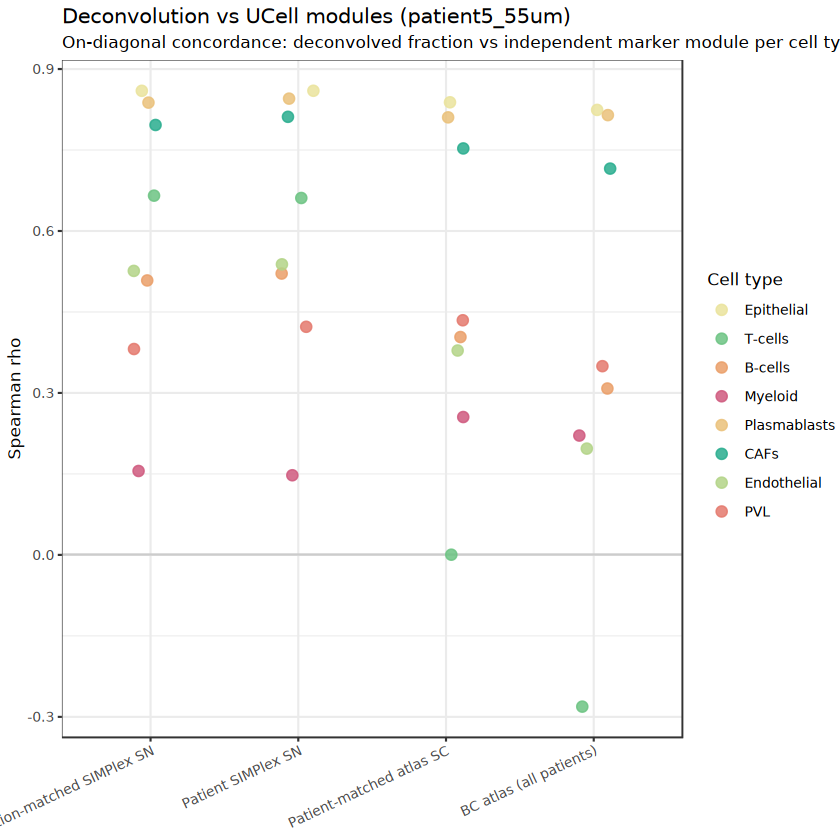

In [25]:
# --- 3. Deconvolution fidelity vs independent marker modules ---
genesets <- list(
  epithelial = c("EPCAM", "KRT8", "KRT5", "KRT14", "CDH1", "MUC1", "CLDN3", "CLDN4", "CLDN7"),
  tcell = c("CD3D", "CD3E", "CD3G", "CD2", "TRAC"),
  bcell = c("CD79B", "MS4A1", "BANK1"),
  myeloid = c("ITGAM", "MRC1", "CD68", "FUT4", "FCGR3A"),
  plasmablast = c("XBP1", "PRDM1", "JCHAIN", "IGHG1"),
  fibroblast = c("COL1A1", "COL1A2", "DCN", "FAP", "MMP2", "MMP11", "THY1"),
  endothelial = c("PECAM1", "VWF", "CDH5", "ESAM", "TIE1", "TEK", "FLT1", "KDR", "CLDN5", "PLVAP", "PROX1", "LYVE1", "PDPN"),
  pvl = c("MCAM", "ACTA2", "PDGFRB")
)

correspondences <- c(
  "Epithelial" = "epithelial",
  "T-cells" = "tcell",
  "B-cells" = "bcell",
  "Myeloid" = "myeloid",
  "Plasmablasts" = "plasmablast",
  "CAFs" = "fibroblast",
  "Endothelial" = "endothelial",
  "PVL" = "pvl"
)

# UCell module scores on spatial (reuse deposited assay when present)
if (!"celltype_modules_UCell" %in% Assays(vis_p5)) {
  if (requireNamespace("UCell", quietly = TRUE)) {
    vis_p5 <- JoinLayers(vis_p5)
    DefaultAssay(vis_p5) <- "Spatial"
    vis_p5 <- UCell::AddModuleScore_UCell(vis_p5, features = genesets)
    module_mat <- vis_p5@meta.data[, paste0(names(genesets), "-markers-UCell"), drop = FALSE]
    colnames(module_mat) <- names(genesets)
    vis_p5[["celltype_modules_UCell"]] <- CreateAssayObject(data = t(as.matrix(module_mat)))
  } else {
    DefaultAssay(vis_p5) <- "Spatial"
    mat <- as.matrix(get_data_mat(vis_p5, "Spatial"))
    score_list <- lapply(genesets, function(g) {
      g <- intersect(g, rownames(mat))
      if (length(g) < 2) return(rep(NA_real_, ncol(mat)))
      colMeans(mat[g, , drop = FALSE], na.rm = TRUE)
    })
    module_mat <- do.call(cbind, score_list)
    colnames(module_mat) <- names(genesets)
    vis_p5[["celltype_modules_UCell"]] <- CreateAssayObject(data = t(module_mat))
  }
}

prep_ref <- function(ref) {
  DefaultAssay(ref) <- "RNA"
  ref |>
    NormalizeData(verbose = FALSE) |>
    FindVariableFeatures(nfeatures = 2000, verbose = FALSE)
}

prep_vis <- function(vis) {
  DefaultAssay(vis) <- "Spatial"
  if (inherits(vis[["Spatial"]], "Assay5")) {
    vis <- JoinLayers(vis, assay = "Spatial")
  }
  vis |>
    NormalizeData(verbose = FALSE) |>
    FindVariableFeatures(nfeatures = nrow(vis), verbose = FALSE) |>
    ScaleData(verbose = FALSE)
}

run_nnls_map <- function(vis, ref, ident, assay_name) {
  vis <- prep_vis(vis)
  ref <- prep_ref(ref)
  RunNNLS(
    vis,
    singlecell_object = ref,
    spatial_assay = "Spatial",
    singlecell_assay = "RNA",
    groups = ident,
    slot = "data",
    assay_name = assay_name
  )
}

decon_specs <- list(
  list(label = "Section-matched SIMPlex SN", ref = refs[[1]], ident = sn_ident, assay = "section_sn_map"),
  list(label = "Patient SIMPlex SN", ref = refs[[2]], ident = sn_ident, assay = "patient_sn_map"),
  list(label = "Patient-matched atlas SC", ref = refs[[3]], ident = sc_ident, assay = "patsc_map"),
  list(label = "BC atlas (all patients)", ref = refs[[4]], ident = sc_ident, assay = "atlas_map")
)

# Reuse deposited maps when available (manuscript objects)
existing_maps <- c(
  "Patient SIMPlex SN" = "patspec_major_map",
  "BC atlas (all patients)" = "garvan_major_map"
)
for (nm in names(existing_maps)) {
  if (existing_maps[[nm]] %in% Assays(vis_p5)) {
    idx <- which(vapply(decon_specs, function(x) x$label == nm, logical(1)))
    decon_specs[[idx]]$assay <- existing_maps[[nm]]
    decon_specs[[idx]]$skip_run <- TRUE
  }
}

for (spec in decon_specs) {
  if (!isTRUE(spec$skip_run) && !(spec$assay %in% Assays(vis_p5))) {
    message("Running NNLS: ", spec$label)
    vis_p5 <- run_nnls_map(vis_p5, spec$ref, spec$ident, spec$assay)
  }
}

DefaultAssay(vis_p5) <- "celltype_modules_UCell"
module_feats <- rownames(vis_p5[["celltype_modules_UCell"]])
module_mat <- FetchData(vis_p5, vars = module_feats)
colnames(module_mat) <- gsub("-markers-UCell$", "", colnames(module_mat))

ref_levels <- vapply(decon_specs, `[[`, character(1), "label")

cor_list <- list()
for (spec in decon_specs) {
  if (!(spec$assay %in% Assays(vis_p5))) {
    warning("Deconvolution assay not found, skipping: ", spec$label, " (", spec$assay, ")")
    next
  }
  decon_feats <- rownames(vis_p5[[spec$assay]])
  DefaultAssay(vis_p5) <- spec$assay
  decon_mat <- FetchData(vis_p5, vars = decon_feats)
  for (ct in names(correspondences)) {
    mod <- correspondences[[ct]]
    decon_col <- gsub("_", "-", ct)
    if (decon_col %in% colnames(decon_mat) && mod %in% colnames(module_mat)) {
      cor_list[[length(cor_list) + 1]] <- tibble(
        reference = spec$label,
        celltype = ct,
        spearman = suppressWarnings(
          cor(decon_mat[, decon_col], module_mat[, mod], method = "spearman", use = "pairwise.complete.obs")
        )
      )
    }
  }
}

if (length(cor_list) == 0) {
  stop(
    "No deconvolution vs module correlations computed. ",
    "Check that deconvolution assays exist on vis_p5 and UCell module names match. ",
    "Assays present: ", paste(Assays(vis_p5), collapse = ", ")
  )
}

decon_cor_df <- bind_rows(cor_list) %>%
  mutate(
    reference = factor(reference, levels = intersect(ref_levels, unique(reference))),
    celltype = factor(celltype, levels = names(correspondences))
  )

summary_df <- decon_cor_df %>%
  group_by(reference) %>%
  summarise(
    mean_spearman = mean(spearman, na.rm = TRUE),
    median_spearman = median(spearman, na.rm = TRUE),
    n_celltypes = sum(!is.na(spearman)),
    .groups = "drop"
  ) %>%
  arrange(desc(mean_spearman))

write.csv(decon_cor_df, file.path(wd_snsc, "deconv_module_correlation.csv"), row.names = FALSE)
write.csv(summary_df, file.path(wd_snsc, "deconv_module_correlation_summary.csv"), row.names = FALSE)

cat("\nMean module concordance by reference:\n")
print(summary_df)

p_decon <- ggplot(decon_cor_df, aes(x = reference, y = spearman, colour = celltype)) +
  geom_hline(yintercept = 0, colour = "grey80") +
  geom_point(position = position_jitter(width = 0.12), size = 2.5, alpha = 0.85) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.55, fatten = 0, colour = "black") +
  scale_colour_manual(values = colsCelltype) +
  labs(
    title = paste0("Deconvolution vs UCell modules (", SAMPLE, ")"),
    subtitle = "On-diagonal concordance: deconvolved fraction vs independent marker module per cell type",
    x = NULL, y = "Spearman rho", colour = "Cell type"
  ) +
  theme_bw(base_size = 10) +
  theme(axis.text.x = element_text(angle = 25, hjust = 1))

ggsave(file.path(wd_snsc, "deconv_module_correlation.pdf"), p_decon, width = 8, height = 5)
print(p_decon)

**How to read this for the reviewer**

| Panel | Take-home |
|-------|-----------|
| Composition | H&E + CTA use base **Epithelial / Stroma / Immune** colours; reference bars keep major types as lighter shades within the same hue family. |
| Pseudobulk ρ | SN–Visium > SC–Visium for the same patient — Visium is nuclear RNA, so SN is the biologically matched modality even when the patient matches. |
| Deconv vs modules | Section-matched SN reference gives the highest mean on-diagonal Spearman vs independent UCell modules; patient-matched SC and the full atlas lag behind. |

Together: patient identity alone is not enough — **modality (nuclei) and section context** matter for reference quality and deconvolution fidelity.